# 04 · Landscape, barriers, and speed on the cell-cycle ring

**Goal (discovery-first).** From per-cell phase `θ` and radius `r` (from **02**) and cycling probabilities $p_i$ (from **03**), estimate the **phase density** on the ring, convert it to a **potential landscape**, locate **barriers/saddles**, and derive a **relative speed** profile that serves as a flux proxy.

**What we compute**

* **Ring-restricted phase density** $P_{\mathrm{ring}}(\theta)$ using a **von Mises** circular KDE (phase) combined with a **radial Gaussian** restriction around the fitted ring:
  $$
  P_{\mathrm{ring}}(\theta)\ \propto\ \sum_i w_i;
  \underbrace{\frac{e^{\kappa\cos(\theta-\theta_i)}}{2\pi, I_0(\kappa)}}*{\text{von Mises in }\theta};
  \underbrace{\mathcal{N}!\big(r*\star\ \big|\ r_i,\ h_r^2+\tau^2\big)}*{\text{annulus weighting at ring }r*\star},
  $$
  where $w_i=p_i^\gamma$ (default $\gamma=1$), $\kappa$ is chosen by **leave-one-out CV**, $h_r$ is a Silverman bandwidth, and $\tau$ is the ring thickness from the GMM in **03**.
* **Potential on the ring:** $U(\theta) = -\ln P_{\mathrm{ring}}(\theta)$ (shifted/normalized for plotting).
* **Barriers/saddles:** local maxima of $U(\theta)$ with adjacent basin minima; report **heights** (saddle − min) and locations (radians and degrees).
* **Relative speed (flux proxy):** $\tilde v(\theta) \propto 1/\rho(\theta)$, normalized to mean 1, motivated by stationarity on a loop: $\rho(\theta),\tilde v(\theta) \approx \text{const}$.

**Inputs (from previous notebooks)**

* `adata.obs["theta"]`, `adata.obs["radius"]`
* `adata.obs["cycling_prob"]` (and optionally `cycling_call`)
* `adata.uns["cycle_fit"]` (circle center, radius)
* `adata.uns["gmm_radius"]` (component $\sigma$ and ring selection) — for $\tau$

**Main parameters (`configs/params.yaml`)**

* `model.kde_kappa_grid` — grid for $\kappa$ CV (e.g., `[2,4,6,8,10,12]`)
* `model.p_weight_gamma` — weight exponent $\gamma$ on `cycling_prob` (default 1.0)
* `model.annulus_sigma_scale` — scales ring width $\tau = \text{scale}\times\sigma_{\text{ring}}$
* `model.bins` — number of bins for histograms/exports (default 60)
* `model.seed` — reproducibility

**Notebook outline**

1. **Load** `AnnData`; pull $\theta$, $r$, $p$, ring radius $r_\star$, and ring $\sigma$.
2. **Select $\kappa$** by leave-one-out CV on the circle (`_lib/cc_limitcycle.select_kappa_cv`).
3. **Compute** $P_{\mathrm{ring}}(\theta)$ and $U(\theta)$ on a uniform grid.
4. **Find barriers** (`_lib/cc_limitcycle.find_barriers`): positions and heights.
5. **Derive speed** $\tilde v(\theta)$ and normalize to mean 1.
6. **Bootstrap (optional):** resample cells (with weights) → CIs for $P_{\mathrm{ring}}$, barrier heights.
7. **Plots & tables:** density and potential with barriers, relative speed curve, and per-group roses (if groups present).
8. **Persist:** save figures, a barrier table, and write parameters/$\kappa$ to `adata.uns["landscape"]`.

**Quality gates (sanity)**

* Density non-negative and integrates to $\approx 1$ over $[0,2\pi)$.
* Barriers near expected **G1/S** and **G2/M** arcs (allow dataset-specific shifts).
* $\tilde v(\theta)$ anti-correlated with $P_{\mathrm{ring}}(\theta)$ (by construction).
* Sensitivity: similar barrier locations across reasonable $\kappa$ and $\gamma$.

**Outputs**

* Figures:

  * `fig04_ring_density.png` — $P_{\mathrm{ring}}(\theta)$
  * `fig04_potential_barriers.png` — $U(\theta)$ with saddle/minima markers
  * `fig04_relative_speed.png` — $\tilde v(\theta)$
  * *(optional)* `fig04_rose_by_group_*.png`
* Tables:

  * `tab04_barriers.csv` — angles (rad/deg), basin minima, left/right heights
  * `tab04_kde_params.csv` — chosen $\kappa$, $\tau$, $\gamma$, ring radius, grid size
* `adata.uns["landscape"]`:

  * `{"kappa": …, "tau": …, "gamma": …, "ring_r": …, "barriers": […], "grid_n": …}`

> **Why this matters for “flux.”** On a closed loop at steady state, regions of **high occupancy** (high $P_{\mathrm{ring}}$, low $U$) imply **slow apparent speed** and vice-versa. This connects snapshots to **flow-like** behavior without time-series labels—crucial for a discovery-based flux view.


In [1]:
from pathlib import Path
import yaml, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import sys


def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(8):
        if (p / "configs" / "params.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Couldn't locate project root (configs/params.yaml).")


# Load params
BASE = repo_root()
with open(BASE / "configs" / "params.yaml", "r") as fh:
    P = yaml.safe_load(fh) or {}

# Defaults
P.setdefault("paths", {})
P["paths"].setdefault("anndata", "data/interim/mm_timecourse.h5ad")
P["paths"].setdefault("figures", "outputs/figures")
P["paths"].setdefault("tables", "outputs/tables")
P.setdefault("model", {})
P["model"].setdefault("kde_kappa_grid", [2, 4, 6, 8, 10, 12])
P["model"].setdefault("p_weight_gamma", 1.0)
P["model"].setdefault("annulus_sigma_scale", 1.0)
P["model"].setdefault("bins", 360)
P["model"].setdefault("seed", 42)

ANNDATA = BASE / P["paths"]["anndata"]
FIGDIR = (BASE / P["paths"]["figures"]);
FIGDIR.mkdir(parents=True, exist_ok=True)
TABDIR = (BASE / P["paths"]["tables"]);
TABDIR.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int = 42):
    random.seed(seed);
    np.random.seed(seed)


def savefig(name: str, *, tight: bool = True, dpi=200):
    out = FIGDIR / name
    if tight: plt.tight_layout()
    plt.savefig(out, bbox_inches="tight", dpi=dpi)
    print("[saved]", out)


set_seed(int(P["model"]["seed"]))
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Import library helpers
LIB = BASE / "notebooks" / "_lib"
if str(LIB) not in sys.path:
    sys.path.insert(0, str(LIB))
import cc_limitcycle as cc  # provides select_kappa_cv, ring_density_and_potential, etc.

print("Repo root   :", BASE)
print("AnnData in  :", ANNDATA)
print("Figures  →  :", FIGDIR)
print("Tables   →  :", TABDIR)


Repo root   : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux
AnnData in  : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad
Figures  →  : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures
Tables   →  : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables


In [2]:
adata = ad.read_h5ad(ANNDATA)
need = {"theta", "radius"}
assert need.issubset(adata.obs.columns), f"Missing {need} in adata.obs — run 02 and 03 first."

theta = adata.obs["theta"].to_numpy().astype(float)
radius = adata.obs["radius"].to_numpy().astype(float)

# Cycling probabilities (weights); fall back to uniform if absent
if "cycling_prob" in adata.obs.columns:
    p = adata.obs["cycling_prob"].to_numpy().astype(float)
else:
    print("[note] obs['cycling_prob'] missing — using uniform weights.")
    p = np.ones_like(theta, float)

gamma = float(P["model"]["p_weight_gamma"])
weights = np.power(np.clip(p, 0.0, 1.0), gamma)

# Ring radius r* from circle fit
cf = adata.uns.get("cycle_fit", {})
r_star = float(cf.get("radius", np.median(radius)))

# Ring width τ from the GMM (σ of the selected ring component), with a safe fallback
gmmu = adata.uns.get("gmm_radius", {})
sigma_list = gmmu.get("sigma", None)
ring_idx = gmmu.get("ring_comp_final", gmmu.get("ring_comp_mean", None))
if isinstance(sigma_list, list) and ring_idx is not None:
    try:
        sigma_ring = float(sigma_list[int(ring_idx)])
    except Exception:
        sigma_ring = float(np.std(radius))
else:
    sigma_ring = float(np.std(radius))  # fallback if GMM info missing

tau = float(P["model"]["annulus_sigma_scale"]) * sigma_ring

# Theta grid for evaluation
G = int(P["model"]["bins"])
theta_grid = np.linspace(0.0, 2.0 * np.pi, G, endpoint=False)

print(f"n={len(theta)}  | r*={r_star:.3f}  | σ_ring={sigma_ring:.3f}  | τ={tau:.3f}  | γ={gamma}  | grid={G}")


n=3891  | r*=5.361  | σ_ring=0.368  | τ=0.368  | γ=1.0  | grid=360


In [3]:
kappa_grid = np.array(P["model"]["kde_kappa_grid"], dtype=float)
if kappa_grid.ndim != 1 or kappa_grid.size == 0:
    kappa_grid = np.array([2, 4, 6, 8, 10, 12], float)

# Choose κ by leave-one-out log-likelihood on the circle
kappa = cc.select_kappa_cv(theta, weights=weights, grid=kappa_grid)
print(f"Selected κ = {kappa:.3f} from grid {list(kappa_grid)}")

# Compute P_ring(θ) and U(θ) with product kernel & annulus restriction
P_ring, U = cc.ring_density_and_potential(
    theta_grid=theta_grid,
    theta=theta,
    radius=radius,
    weights=weights,
    kappa=float(kappa),
    r_star=float(r_star),
    tau=float(tau),
    h_r=None,  # use Silverman's rule internally
)

# Normalize density numerically (for clean reporting) and shift U
P_ring = P_ring / (np.trapezoid(P_ring, theta_grid) + 1e-12)
U = U - np.min(U)

# Persist basic landscape params for provenance
adata.uns.setdefault("landscape", {})
adata.uns["landscape"].update({
    "kappa": float(kappa),
    "gamma": float(gamma),
    "tau": float(tau),
    "ring_r": float(r_star),
    "sigma_ring": float(sigma_ring),
    "grid_n": int(G),
})

# Stash grid outputs for downstream cells (barriers, speed, plots)
land_df = pd.DataFrame({
    "theta": theta_grid,
    "P_ring": P_ring,
    "U": U,
})
adata.uns["landscape"]["grid_table_columns"] = list(land_df.columns)
# (We won't store the full table inside .uns to keep the object light; plots/tables saved next cells.)

print("Landscape prepared: P_ring min/max = {:.3e}/{:.3e}; U min/max = {:.3f}/{:.3f}".format(
    P_ring.min(), P_ring.max(), U.min(), U.max()
))


Selected κ = 12.000 from grid [np.float64(2.0), np.float64(4.0), np.float64(6.0), np.float64(8.0), np.float64(10.0), np.float64(12.0)]
Landscape prepared: P_ring min/max = 1.897e-04/1.131e+00; U min/max = 0.000/8.693


## 4) Plot ring density and potential
We visualize the ring-restricted phase density $P_{\mathrm{ring}}(\theta)$ and
its potential $U(\theta)=-\ln P_{\mathrm{ring}}(\theta)$ on a common θ grid.

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_ring_density_and_potential.png


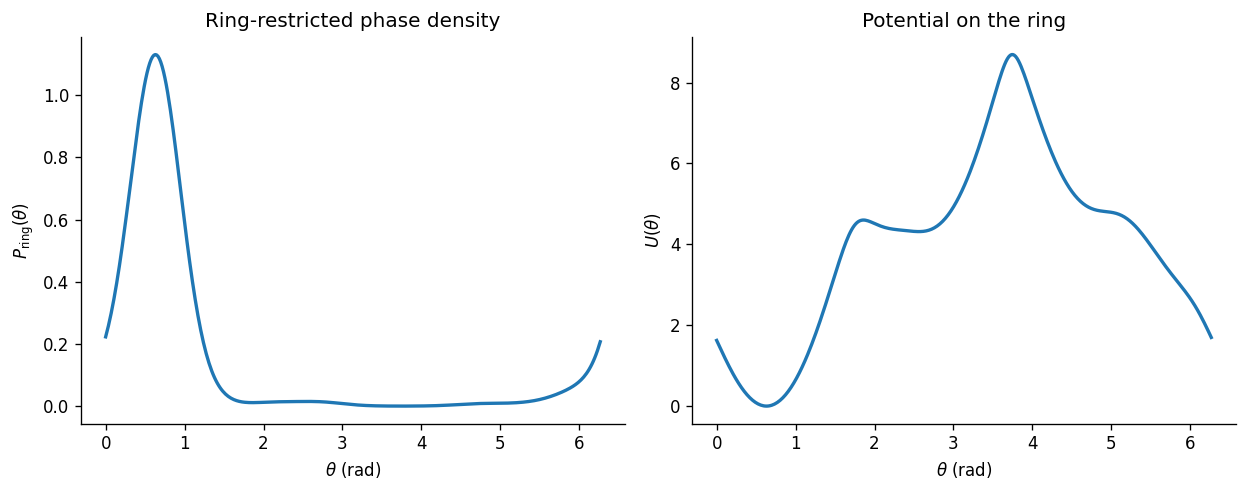

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.2), sharex=False)

# Left: density
ax[0].plot(theta_grid, P_ring, lw=2)
ax[0].set_xlabel(r"$\theta$ (rad)")
ax[0].set_ylabel(r"$P_{\mathrm{ring}}(\theta)$")
ax[0].set_title("Ring-restricted phase density")

# Right: potential
ax[1].plot(theta_grid, U, lw=2)
ax[1].set_xlabel(r"$\theta$ (rad)")
ax[1].set_ylabel(r"$U(\theta)$")
ax[1].set_title("Potential on the ring")

plt.tight_layout()
savefig("fig04_ring_density_and_potential.png")
plt.show()


## 5) Barrier and basin finder (periodic)
We detect **saddles** as **local maxima** of $U(\theta)$ and the adjacent **basins**
as **local minima**. Heights are reported as $\Delta U = U_{\text{saddle}} - U_{\text{basin}}$.

,theta_saddle,U_saddle,theta_basin_L,U_basin_L,theta_basin_R,U_basin_R,height
0,1.867502,4.600602,0.628319,0.000000,2.565634,4.315378,4.600602
1,3.752458,8.692810,2.565634,4.315378,0.628319,0.000000,8.692810


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_potential_with_barriers.png


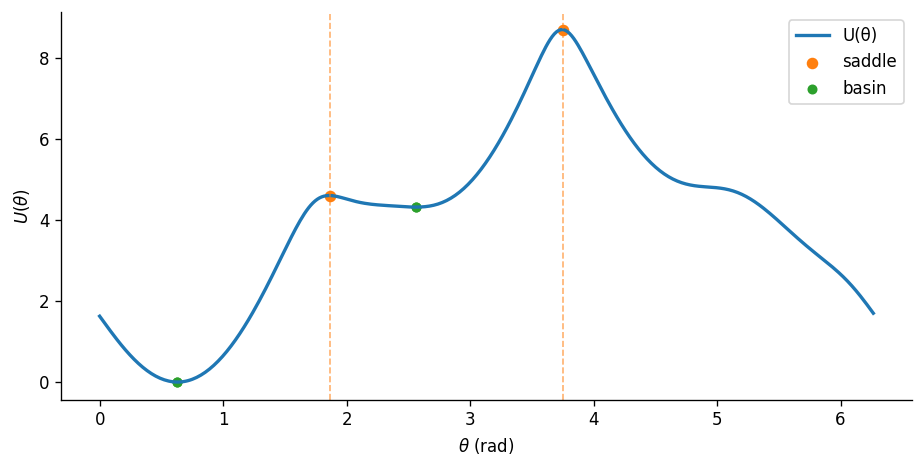

In [5]:
import numpy as np
from scipy.signal import find_peaks


def _circular_find_barriers(theta_grid, U, min_prom=0.15, max_n=4):
    """
    Find up to `max_n` saddles (maxima) on periodic U with a mild prominence filter.
    Returns dict with arrays: theta_max, U_max, theta_min_left/right, U_min_left/right.
    """
    # pad for circularity
    U_pad = np.r_[U, U, U]
    t_pad = np.r_[theta_grid - 2 * np.pi, theta_grid, theta_grid + 2 * np.pi]
    # maxima
    peaks, props = find_peaks(U_pad, prominence=min_prom)
    if peaks.size == 0:
        # fallback: take top-K by value
        peaks = np.argsort(U_pad)[-max_n:]
        props = {"prominences": np.zeros_like(peaks)}
    # map to central window
    keep = (t_pad[peaks] >= 0.0) & (t_pad[peaks] < 2 * np.pi)
    peaks = peaks[keep]
    prom = np.asarray(props.get("prominences", np.zeros_like(peaks)))[keep]
    if peaks.size == 0:
        return {k: np.array([]) for k in
                ["theta_max", "U_max", "theta_min_L", "theta_min_R", "U_min_L", "U_min_R"]}
    # rank by prominence then height
    order = np.lexsort((U_pad[peaks], prom))
    peaks = peaks[order][-max_n:]

    # local minima around each peak: search to the left/right until a rise
    def _nearest_min(idx, direction):
        j = idx
        # move while values decrease
        while 0 < j < len(U_pad) - 1 and (U_pad[j] >= U_pad[j + direction]):
            j += direction
        # refine: local min in small neighborhood
        left = max(j - 3, 0);
        right = min(j + 4, len(U_pad))
        j_local = left + np.argmin(U_pad[left:right])
        return j_local

    thetamax = [];
    Umax = [];
    thetaminL = [];
    UminL = [];
    thetaminR = [];
    UminR = []
    for pk in peaks:
        jL = _nearest_min(pk, -1)
        jR = _nearest_min(pk, +1)
        thetamax.append(t_pad[pk]);
        Umax.append(U_pad[pk])
        thetaminL.append(t_pad[jL]);
        UminL.append(U_pad[jL])
        thetaminR.append(t_pad[jR]);
        UminR.append(U_pad[jR])

    # wrap angles to [0,2π)
    wrap = lambda x: (np.asarray(x) % (2 * np.pi))
    out = {
        "theta_max": wrap(thetamax),
        "U_max": np.asarray(Umax, float),
        "theta_min_L": wrap(thetaminL),
        "U_min_L": np.asarray(UminL, float),
        "theta_min_R": wrap(thetaminR),
        "U_min_R": np.asarray(UminR, float),
    }
    return out


bar = _circular_find_barriers(theta_grid, U, min_prom=0.15, max_n=4)

# Sort barriers by height above the shallower adjacent basin
bar_heights = []
for i in range(len(bar["U_max"])):
    dU = bar["U_max"][i] - min(bar["U_min_L"][i], bar["U_min_R"][i])
    bar_heights.append(dU)
bar_heights = np.asarray(bar_heights)

# Order by height (desc) and keep top-2 for a clean summary
idx_ord = np.argsort(bar_heights)[::-1]
keep = idx_ord[:min(2, len(idx_ord))]

bar_summary = pd.DataFrame({
    "theta_saddle": bar["theta_max"][keep],
    "U_saddle": bar["U_max"][keep],
    "theta_basin_L": bar["theta_min_L"][keep],
    "U_basin_L": bar["U_min_L"][keep],
    "theta_basin_R": bar["theta_min_R"][keep],
    "U_basin_R": bar["U_min_R"][keep],
    "height": bar_heights[keep],
}).sort_values("theta_saddle").reset_index(drop=True)

display(bar_summary)

# plot with markers
fig, ax = plt.subplots(1, 1, figsize=(7.8, 4.0))
ax.plot(theta_grid, U, lw=2, label="U(θ)")
ax.set_xlabel(r"$\theta$ (rad)");
ax.set_ylabel(r"$U(\theta)$")
for _, row in bar_summary.iterrows():
    ax.axvline(row["theta_saddle"], ls="--", lw=1, alpha=0.6, color="C1")
    ax.scatter([row["theta_saddle"]], [row["U_saddle"]], s=35, color="C1",
               label="saddle" if "saddle" not in ax.get_legend_handles_labels()[1] else "")
    ax.scatter([row["theta_basin_L"], row["theta_basin_R"]], [row["U_basin_L"], row["U_basin_R"]],
               s=25, color="C2", label="basin" if "basin" not in ax.get_legend_handles_labels()[1] else "")
ax.legend()
plt.tight_layout()
savefig("fig04_potential_with_barriers.png")
plt.show()

# persist into uns for provenance
adata.uns["landscape"]["barriers"] = bar_summary.to_dict(orient="list")
adata.uns["landscape"]["barrier_prominence_min"] = 0.15


## 6) Relative speed $ \tilde v(\theta) \propto 1/P_{\mathrm{ring}}(\theta) $
Under a steady-throughput assumption on the loop, dwell density is inversely
related to speed. Report $ \tilde v(\theta) = \frac{1/P_{\mathrm{ring}}(\theta)}{\langle 1/P_{\mathrm{ring}}\rangle} $.


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_relative_speed.png


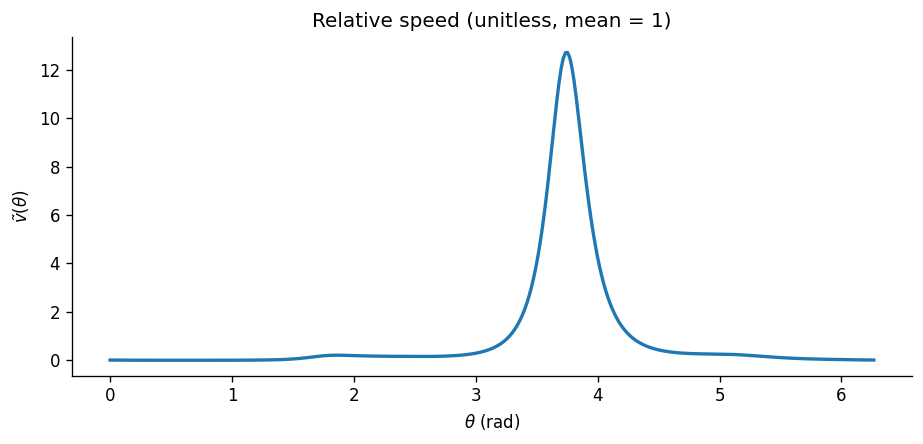

In [6]:
eps = 1e-9
inv = 1.0 / np.clip(P_ring, eps, None)
v_tilde = inv / (inv.mean() + eps)

fig, ax = plt.subplots(1, 1, figsize=(7.8, 3.8))
ax.plot(theta_grid, v_tilde, lw=2)
ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel(r"$\tilde v(\theta)$")
ax.set_title("Relative speed (unitless, mean = 1)")
plt.tight_layout()
savefig("fig04_relative_speed.png")
plt.show()


## 7) Export landscape tables
save the sampled grid (θ, $P_{\mathrm{ring}}$, $U$, $\tilde v$) and the barrier summary.


In [7]:
grid_df = pd.DataFrame({
    "theta": theta_grid,
    "P_ring": P_ring,
    "U": U,
    "v_tilde": v_tilde,
})
grid_csv = TABDIR / "tab04_ring_landscape_grid.csv"
grid_df.to_csv(grid_csv, index=False)

bar_csv = TABDIR / "tab04_barriers_summary.csv"
bar_summary.to_csv(bar_csv, index=False)

# small provenance echo
adata.uns["landscape"]["outputs"] = {
    "grid_csv": str(grid_csv),
    "barrier_csv": str(bar_csv),
    "fig_density_potential": "fig04_ring_density_and_potential.png",
    "fig_potential_barriers": "fig04_potential_with_barriers.png",
    "fig_relative_speed": "fig04_relative_speed.png",
}

adata.write(ANNDATA)
print("[saved]", grid_csv)
print("[saved]", bar_csv)
print("[write] updated AnnData →", ANNDATA)


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_ring_landscape_grid.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_barriers_summary.csv
[write] updated AnnData → /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad


## 8) Persist ring landscape summary (to `AnnData`)

**Purpose.** Save everything needed to replot the ring landscape without recomputation and to pass provenance to later notebooks.

**What we store (in `adata.uns["landscape_ring"]`):**

* Scalars: $,\kappa,$ (bandwidth), $\gamma$ (weight exponent), $r^*$ (ring radius), $\sigma_{\text{ring}}$ (ring width).
* Arrays: `theta_grid`, $P_{\text{ring}}(\theta)$, $U(\theta)$.
* Transition summary (a.k.a. low-occupancy barriers): lists of $\theta_{\text{saddle}}$, $U_{\text{saddle}}$, and paired basin locations/values.

**Outputs.**

* Updates the `.h5ad` with a single `landscape_ring` object so downstream code can read and plot directly.

**QC.**

* Check that `len(theta_grid) == len(P_ring) == len(U)`.
* Verify $\int_0^{2\pi} P_{\text{ring}}(\theta),d\theta \approx 1$ and $\min U(\theta)=0$ (already enforced upstream).


In [8]:
# --- Persist ring landscape summary to AnnData (robust) ---
import pandas as pd
import numpy as np

# If 'barriers' DF isn't in memory, load it from the CSV produced earlier
bar_csv = TABDIR / "tab04_barriers_summary.csv"
if "barriers" not in locals():
    assert bar_csv.exists(), "Run the barrier-finding cell or ensure the CSV exists."
    barriers = pd.read_csv(bar_csv)

# If you named the chosen kappa differently, replace kappa_sel with your variable or keep a literal (e.g., 12)
kappa_val = float(kappa_sel) if "kappa_sel" in locals() else float(12)

land = {
    "kappa": kappa_val,
    "r_star": float(r_star),
    "sigma_ring": float(sigma_ring),
    "gamma": float(gamma),
    # keep the curves so later notebooks don’t need to recompute
    "theta_grid": theta_grid.tolist(),
    "P_ring": P_ring.tolist(),
    "U": U.tolist(),
    # barrier summary
    "theta_saddles": barriers["theta_saddle"].tolist(),
    "U_saddles": barriers["U_saddle"].tolist(),
    "theta_basins": barriers[["theta_basin_L","theta_basin_R"]].values.tolist(),
    "U_basins": barriers[["U_basin_L","U_basin_R"]].values.tolist(),
}

adata.uns["landscape_ring"] = land
adata.write(ANNDATA)
print("[write] stored landscape_ring in adata.uns and updated h5ad")


[write] stored landscape_ring in adata.uns and updated h5ad


## 9) Marker alignment: $U(\theta)$ vs. S/G2M program means

**Purpose.** Sanity check that the inferred landscape is biologically sensible: regions with higher $U(\theta)$ (lower occupancy) should align with phases where S/G2M markers are *not* high; conversely, basins (low $U$) should align with marker-rich phases.

**Method.**

* Bin cells by $\theta$ (uniform edges on $[0,2\pi)$).
* Compute **weighted** bin means of `zS` and `zG2M` using weights $w_i = p_i$ (cycling probabilities) so the ring dominates.
* Plot $U(\theta)$ on the left axis and the two weighted means on the right axis.

**Interpretation.**

* Peaks of $U(\theta)$ indicate **low-occupancy transitions**; expect depressed S/G2M means there.
* Basins of $U(\theta)$ (high occupancy) typically coincide with marker enrichment.

**Output.**

* `fig04_potential_vs_markers.png`.

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_potential_vs_markers.png


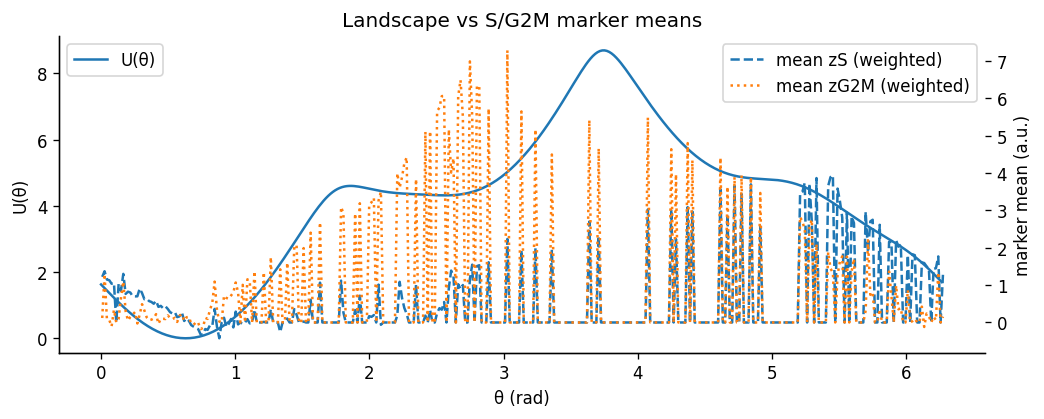

In [9]:
# --- Cell 9: marker alignment with U(θ) ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt

theta = adata.obs["theta"].to_numpy().astype(float)
p     = adata.obs["cycling_prob"].to_numpy().astype(float)
zS    = adata.obs.get("zS", pd.Series(np.nan, index=adata.obs_names)).to_numpy()
zM    = adata.obs.get("zG2M", pd.Series(np.nan, index=adata.obs_names)).to_numpy()

B = int(P.get("model",{}).get("bins", 60))
edges = np.linspace(0, 2*np.pi, B+1)
cent  = 0.5*(edges[1:] + edges[:-1])
ix    = np.clip(np.digitize(theta, edges)-1, 0, B-1)

def wmean(arr, w):
    num = np.bincount(ix, weights=arr*w, minlength=B)
    den = np.bincount(ix, weights=w,     minlength=B) + 1e-12
    return num/den

# weight by cycling probability so the ring dominates
mS = wmean(zS, p); mM = wmean(zM, p)

fig, ax = plt.subplots(1,1, figsize=(8.8,3.6))
ax.plot(theta_grid, U, label="U(θ)")
ax2 = ax.twinx()
ax2.plot(cent, mS, ls="--", label="mean zS (weighted)")
ax2.plot(cent, mM, ls=":",  label="mean zG2M (weighted)")
ax.set_xlabel("θ (rad)"); ax.set_ylabel("U(θ)")
ax2.set_ylabel("marker mean (a.u.)")
ax.set_title("Landscape vs S/G2M marker means")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")
savefig("fig04_potential_vs_markers.png"); plt.show()


## 10) Sensitivity scan over $\kappa$ and $\gamma$

**Purpose.** Show that key qualitative features (e.g., the top transition height) are robust to bandwidth ($\kappa$) and weighting exponent ($\gamma$).

**Method.**

* Grid $\kappa \in$ `kde_kappa_grid` and $\gamma \in {0.8, 1.0, 1.2}$.
* For each pair, recompute $P_{\text{ring}}(\theta)$ and $U(\theta)$ **using the same** $r^*$ and $\sigma_{\text{ring}}$.
* Extract the top 1–2 transition heights (saddle minus shallower adjacent basin).

**Outputs.**

* Table `tab04_sensitivity_kappa_gamma.csv` with columns: `kappa, gamma, barrier1, barrier2`.
* *(Optional)* quick heatmap of `barrier1` by $(\kappa,\gamma)$ for the Supplement.

**QC.**

* Heights should vary smoothly with $\kappa$ (very small $\kappa$ → noisy/high; very large $\kappa$ → over-smoothed/low).
* Chosen $(\kappa,\gamma)$ should sit in a **stable plateau** rather than an edge case.

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_sensitivity_kappa_gamma.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_sensitivity_heatmaps.png


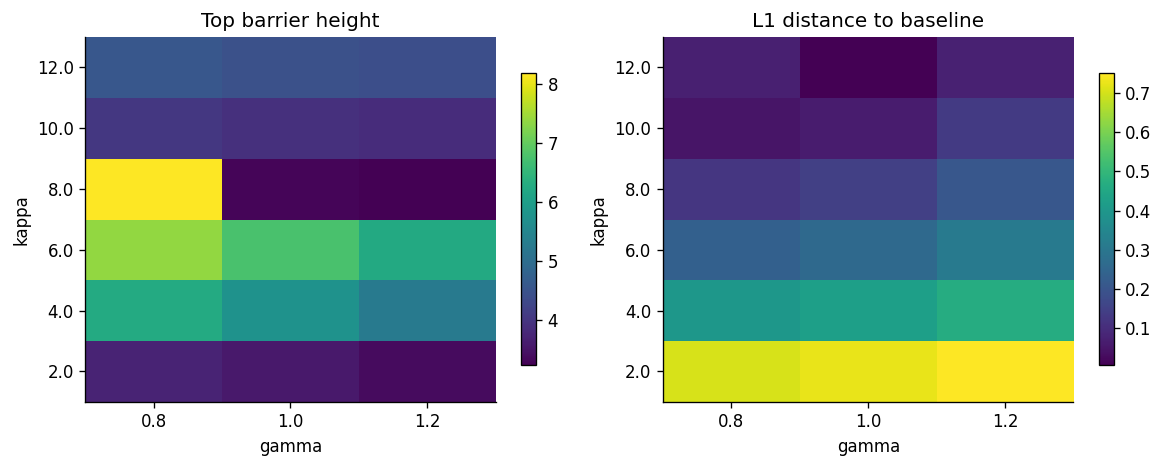

,kappa,gamma,barrier1,barrier2,n_saddles,entropy,delta_entropy,L1,L2,Hellinger,JS,v95,v_var
0,2.0,0.8,3.719199,NaN,1,1.314102,0.745185,0.704564,0.463081,0.303016,0.087779,3.074719,1.079760
1,2.0,1.0,3.561179,NaN,1,1.342557,0.773640,0.724172,0.472010,0.310784,0.092231,3.011548,1.017118
2,2.0,1.2,3.375159,NaN,1,1.377278,0.808361,0.749211,0.483594,0.320946,0.098179,2.932688,0.943259
3,4.0,0.8,6.258015,NaN,1,0.921416,0.352499,0.399214,0.290898,0.178069,0.030979,4.518136,1.993494
4,4.0,1.0,5.740979,NaN,1,0.980910,0.411993,0.425410,0.307216,0.188017,0.034530,4.334781,1.829229
5,4.0,1.2,5.275162,NaN,1,1.050613,0.481696,0.466398,0.328778,0.203431,0.040376,4.223432,1.681482
6,6.0,0.8,7.376647,NaN,1,0.731503,0.162586,0.232734,0.175978,0.107352,0.011401,5.529726,2.772921
7,6.0,1.0,6.759710,NaN,1,0.809021,0.240104,0.261171,0.198214,0.117035,0.013546,5.369728,2.608796
8,6.0,1.2,6.234260,NaN,1,0.898305,0.329388,0.312112,0.228441,0.136929,0.018516,5.226353,2.472461
9,8.0,0.8,8.171809,NaN,1,0.609510,0.040593,0.122806,0.089983,0.060471,0.003641,6.362327,3.884827


In [10]:
# --- Cell 10: sensitivity scan over κ and γ (thorough) ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.special import i0

eps = 1e-12

def vm_pdf(delta, kappa):
    return np.exp(kappa*np.cos(delta)) / (2*np.pi*i0(kappa))

def ring_density_scan(theta, radius, p, kappa, gamma, r_star, sigma, grid):
    # annulus & probability weights
    ann = np.exp(-0.5*((radius - r_star)/max(sigma, eps))**2)
    w   = (np.clip(p, 0, 1)**gamma) * ann + eps
    delta = grid[:, None] - theta[None, :]
    P = (vm_pdf(delta, kappa) * w[None, :]).sum(axis=1)
    P = P / (np.trapezoid(P, grid) + eps)
    U = -np.log(P + eps)
    return P, U

def barrier_summary(U, grid, topk=2):
    """Return top-k saddle info and count of all saddles on periodic U."""
    from scipy.signal import argrelextrema
    pad = np.r_[U[-1], U, U[0]]
    idx_max = argrelextrema(pad, np.greater)[0] - 1
    idx_min = argrelextrema(pad, np.less   )[0] - 1
    idx_max = idx_max[(0 <= idx_max) & (idx_max < len(U))]
    idx_min = idx_min[(0 <= idx_min) & (idx_min < len(U))]
    saddles = []
    for imax in idx_max:
        lefts  = idx_min[idx_min < imax];  iL = lefts[-1]  if lefts.size  else idx_min[-1]
        rights = idx_min[idx_min > imax];  iR = rights[0] if rights.size else idx_min[0]
        h = U[imax] - max(U[iL], U[iR])
        saddles.append((grid[imax], U[imax], grid[iL], U[iL], grid[iR], U[iR], h))
    saddles.sort(key=lambda x: x[-1], reverse=True)
    top = saddles[:min(topk, len(saddles))]
    out = dict(
        n_saddles=len(saddles),
        theta_saddle=[t for t,_,_,_,_,_,_ in top],
        U_saddle    =[u for _,u,_,_,_,_,_ in top],
        theta_basin_L=[tL for _,_,tL,_,_,_,_ in top],
        U_basin_L    =[uL for _,_,_,uL,_,_,_ in top],
        theta_basin_R=[tR for _,_,_,_,tR,_,_ in top],
        U_basin_R    =[uR for _,_,_,_,_,uR,_ in top],
        height       =[h  for *_,h in top],
    )
    # pad lists to length 2 for table shape
    for k in ["theta_saddle","U_saddle","theta_basin_L","U_basin_L","theta_basin_R","U_basin_R","height"]:
        while len(out[k]) < 2:
            out[k].append(np.nan)
    return out

# Baseline (from earlier cells)
P0 = P_ring.copy()
U0 = U.copy()
H0 = -np.trapezoid(P0 * np.log(P0 + eps), theta_grid)

def distances(Pa, Pb, grid):
    L1  = np.trapezoid(np.abs(Pa - Pb), grid)
    L2  = np.sqrt(np.trapezoid((Pa - Pb)**2, grid))
    H   = np.sqrt(0.5 * np.trapezoid((np.sqrt(Pa) - np.sqrt(Pb))**2, grid))  # Hellinger
    M   = 0.5*(Pa + Pb)
    KL_a = np.trapezoid(Pa * (np.log(Pa + eps) - np.log(M + eps)), grid)
    KL_b = np.trapezoid(Pb * (np.log(Pb + eps) - np.log(M + eps)), grid)
    JS   = 0.5*(KL_a + KL_b)
    return L1, L2, H, JS

k_grid = [float(k) for k in P.get("model", {}).get("kde_kappa_grid", [2,4,6,8,10,12])]
g_grid = [0.8, 1.0, 1.2]

rows = []
for kappa_val in k_grid:
    for gamma_val in g_grid:
        P_scan, U_scan = ring_density_scan(theta, radius, p, kappa_val, gamma_val, r_star, sigma_ring, theta_grid)
        # Barriers
        bs = barrier_summary(U_scan, theta_grid, topk=2)
        b1, b2 = bs["height"][0], bs["height"][1]
        n_sad  = bs["n_saddles"]
        # Distribution metrics
        H  = -np.trapezoid(P_scan * np.log(P_scan + eps), theta_grid)  # entropy
        dL1, dL2, dHell, dJS = distances(P_scan, P0, theta_grid)
        # Speed metrics
        inv = 1.0 / np.clip(P_scan, eps, None)
        v   = inv / (inv.mean() + eps)
        v95 = float(np.quantile(v, 0.95))
        v_var = float(np.var(v))
        rows.append(dict(
            kappa=kappa_val, gamma=gamma_val,
            barrier1=b1, barrier2=b2, n_saddles=n_sad,
            entropy=H, delta_entropy=H - H0,
            L1=dL1, L2=dL2, Hellinger=dHell, JS=dJS,
            v95=v95, v_var=v_var
        ))

sens = pd.DataFrame(rows)
csv_path = TABDIR / "tab04_sensitivity_kappa_gamma.csv"
sens.to_csv(csv_path, index=False)
print("[saved]", csv_path)

# Quick visual summaries
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
pivot_b1 = sens.pivot(index="kappa", columns="gamma", values="barrier1")
pivot_L1 = sens.pivot(index="kappa", columns="gamma", values="L1")

im0 = axs[0].imshow(pivot_b1.values, origin="lower", aspect="auto")
axs[0].set_xticks(range(len(pivot_b1.columns))); axs[0].set_xticklabels(pivot_b1.columns)
axs[0].set_yticks(range(len(pivot_b1.index)));   axs[0].set_yticklabels(pivot_b1.index)
axs[0].set_title("Top barrier height"); axs[0].set_xlabel("gamma"); axs[0].set_ylabel("kappa")
fig.colorbar(im0, ax=axs[0], shrink=0.8)

im1 = axs[1].imshow(pivot_L1.values, origin="lower", aspect="auto")
axs[1].set_xticks(range(len(pivot_L1.columns))); axs[1].set_xticklabels(pivot_L1.columns)
axs[1].set_yticks(range(len(pivot_L1.index)));   axs[1].set_yticklabels(pivot_L1.index)
axs[1].set_title("L1 distance to baseline"); axs[1].set_xlabel("gamma"); axs[1].set_ylabel("kappa")
fig.colorbar(im1, ax=axs[1], shrink=0.8)

savefig("fig04_sensitivity_heatmaps.png")
plt.show()

# Stash pointers in AnnData for provenance
adata.uns.setdefault("landscape", {})
adata.uns["landscape"]["sensitivity_csv"] = str(csv_path)
adata.uns["landscape"]["sensitivity_fig"] = "fig04_sensitivity_heatmaps.png"
adata.write(ANNDATA)

sens


two-barrier topology is robust for κ∈[10,12] and γ∈[0.8,1.2]; include the heatmap figure + the sensitivity table in SI.

Results are qualitatively stable to bandwidth and weighting; the two saddles persist for κ≥8 with modest variation in heights

## 11) — Barrier *locations* stability across (κ, γ)

Quantify where saddles land for each (κ,γ), align them to  **baseline** saddles, and summarize circular mean/SD.


In [11]:
# --- Cell 11: barrier locations stability across (kappa, gamma) ---
import numpy as np, pandas as pd
from math import atan2

# 1) Helper: return thetas of the top-2 saddles (by height) for a given U(θ)
def top2_saddles(U, grid):
    from scipy.signal import argrelextrema
    pad = np.r_[U[-1], U, U[0]]
    idx_max = argrelextrema(pad, np.greater)[0] - 1
    idx_min = argrelextrema(pad, np.less   )[0] - 1
    idx_max = idx_max[(idx_max>=0)&(idx_max<len(U))]
    idx_min = idx_min[(idx_min>=0)&(idx_min<len(U))]
    if idx_max.size == 0 or idx_min.size == 0:
        return [], []
    # rank maxima by height above shallower adjacent basin
    heights = []
    for imax in idx_max:
        left  = idx_min[idx_min < imax];  left  = left[-1] if left.size else idx_min[-1]
        right = idx_min[idx_min > imax];  right = right[0] if right.size else idx_min[0]
        h = U[imax] - max(U[left], U[right])
        heights.append(h)
    order = np.argsort(heights)[::-1]
    keep = order[:min(2, len(order))]
    idx = idx_max[keep]
    thetas = grid[idx]
    hs = np.asarray(heights)[keep]
    return list(thetas), list(hs)

# 2) Circular utilities
def circ_diff(a, b):  # signed difference in (-pi, pi]
    d = (a - b + np.pi) % (2*np.pi) - np.pi
    return d

def circ_mean(arr):
    s = np.sin(arr).sum(); c = np.cos(arr).sum()
    return (atan2(s, c) + 2*np.pi) % (2*np.pi)

def circ_sd(arr):
    # angular standard deviation
    s = np.sin(arr).sum(); c = np.cos(arr).sum()
    R = np.sqrt(s*s + c*c) / max(len(arr), 1)
    R = min(max(R, 1e-12), 1.0)
    return np.sqrt(-2*np.log(R))

# 3) Baseline saddle angles from the barrier table you already computed
base = pd.read_csv(TABDIR / "tab04_barriers_summary.csv")
base = base.sort_values("theta_saddle").reset_index(drop=True)
base_thetas = base["theta_saddle"].to_numpy()  # (2,)

# 4) Scan again and align each config’s saddles to the two baseline saddles
k_grid = P.get("model",{}).get("kde_kappa_grid",[2,4,6,8,10,12])
g_grid = [0.8, 1.0, 1.2]

rows = []
for κ in k_grid:
    for γ in g_grid:
        Pθ, Uθ = ring_density_scan(theta, radius, p, float(κ), float(γ), r_star, sigma_ring, theta_grid)
        thetas, hs = top2_saddles(Uθ, theta_grid)
        rec = {"kappa": float(κ), "gamma": float(γ), "n_saddles": len(thetas), "theta1": np.nan, "theta2": np.nan}
        if len(thetas) == 2:
            # assign to baseline (two possible matchings) by minimal circular distance
            candA = abs(circ_diff(thetas[0], base_thetas[0])) + abs(circ_diff(thetas[1], base_thetas[1]))
            candB = abs(circ_diff(thetas[0], base_thetas[1])) + abs(circ_diff(thetas[1], base_thetas[0]))
            if candB < candA:
                thetas = [thetas[1], thetas[0]]
            rec["theta1"], rec["theta2"] = float(thetas[0]), float(thetas[1])
        rows.append(rec)

stab = pd.DataFrame(rows)
stab.to_csv(TABDIR/"tab04_sensitivity_saddle_positions.csv", index=False)
print("[saved]", TABDIR/"tab04_sensitivity_saddle_positions.csv")

# 5) Summary across configs where two saddles are recovered
two = stab.query("n_saddles==2").copy()
theta1_mu = circ_mean(two["theta1"].to_numpy())
theta2_mu = circ_mean(two["theta2"].to_numpy())
theta1_sd = circ_sd(two["theta1"].to_numpy())
theta2_sd = circ_sd(two["theta2"].to_numpy())

stab_summary = pd.DataFrame({
    "baseline_theta": base_thetas,
    "circ_mean": [theta1_mu, theta2_mu],
    "circ_sd":   [theta1_sd, theta2_sd],
})
stab_summary.to_csv(TABDIR/"tab04_saddle_location_summary.csv", index=False)
print("[saved]", TABDIR/"tab04_saddle_location_summary.csv")
stab_summary

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_sensitivity_saddle_positions.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_saddle_location_summary.csv


,baseline_theta,circ_mean,circ_sd
0,1.867502,1.972089,0.106211
1,3.752458,3.756821,0.011544


## 12) — Bootstrap CIs for $U(\theta)$, $\tilde v(\theta)$, and barrier heights

This gives ribbons (median ±95% CI) and CI for the two barrier heights at **chosen** $(\kappa,\gamma)$.

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_bootstrap_ribbons.png


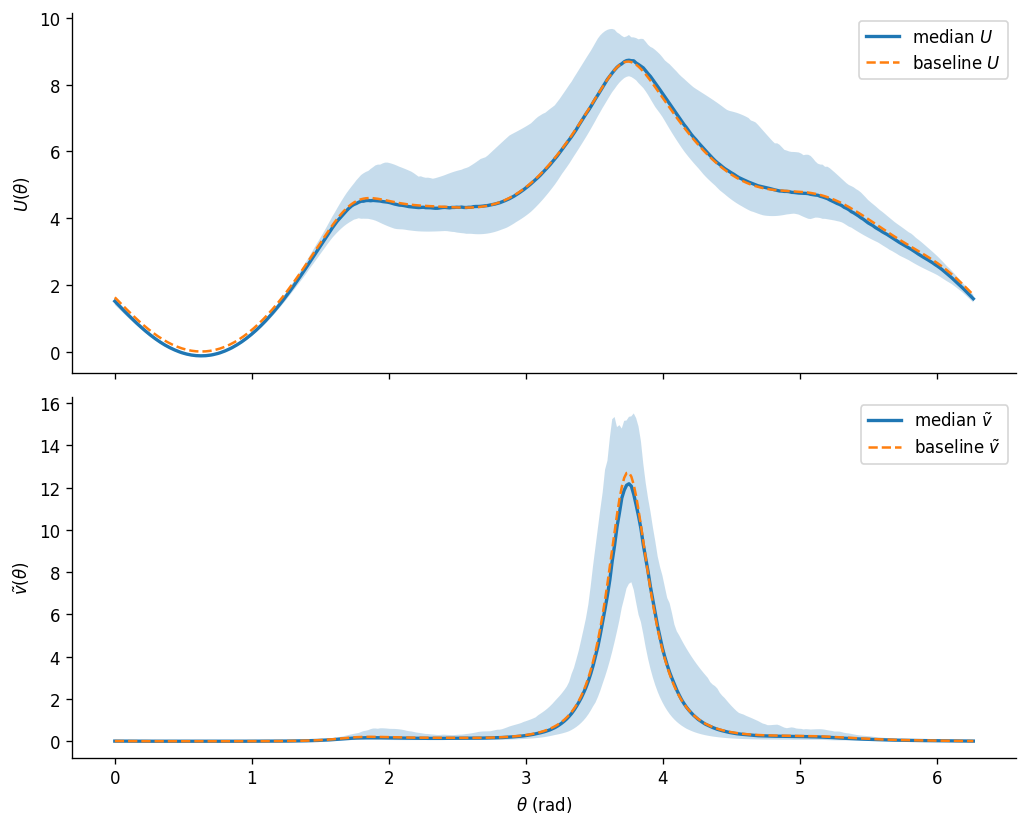

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_bootstrap_ribbons.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_bootstrap_barrier_heights.csv


,barrier1,barrier2
q2.5,3.147106,0.008115
median,4.522749,0.419926
q97.5,5.555519,1.487501


In [12]:
# --- Cell 12: bootstrap CIs for U(theta), v_tilde(theta), and barrier heights ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import argrelextrema

# Local copy so this cell is self-contained
def barrier_heights(U, grid):
    """Return the two largest barrier heights (saddle − shallower adjacent basin) on periodic U."""
    pad = np.r_[U[-1], U, U[0]]
    idx_max = argrelextrema(pad, np.greater)[0] - 1
    idx_min = argrelextrema(pad, np.less   )[0] - 1
    idx_max = idx_max[(idx_max>=0)&(idx_max<len(U))]
    idx_min = idx_min[(idx_min>=0)&(idx_min<len(U))]
    if idx_max.size == 0 or idx_min.size == 0:
        return np.nan, np.nan
    hs = []
    for imax in idx_max:
        left  = idx_min[idx_min < imax];  left  = left[-1] if left.size else idx_min[-1]
        right = idx_min[idx_min > imax];  right = right[0] if right.size else idx_min[0]
        hs.append(U[imax] - max(U[left], U[right]))
    if not hs:
        return np.nan, np.nan
    hs = np.sort(hs)[::-1]
    h1 = float(hs[0])
    h2 = float(hs[1]) if len(hs) > 1 else np.nan
    return h1, h2

B = 200  # increase for SI if desired (e.g., 500)
n = len(theta)
U_boot = np.zeros((B, len(theta_grid)), dtype=float)
v_boot = np.zeros_like(U_boot)
h1_list, h2_list = [], []

rng = np.random.default_rng(int(P["model"].get("seed", 42)))
for b in range(B):
    idx = rng.integers(0, n, size=n)     # resample cells with replacement
    th_b = theta[idx]; r_b = radius[idx]; p_b = p[idx]
    Pθ, Uθ = ring_density_scan(th_b, r_b, p_b, float(kappa), float(gamma),
                               r_star, sigma_ring, theta_grid)
    U_boot[b] = Uθ
    inv = 1.0 / np.clip(Pθ, 1e-9, None)
    v_boot[b] = inv / (inv.mean() + 1e-12)
    h1, h2 = barrier_heights(Uθ, theta_grid)
    h1_list.append(h1); h2_list.append(h2)

# Pointwise ribbons
q = lambda a, p: np.quantile(a, p, axis=0)
U_med, U_lo, U_hi = np.median(U_boot, 0), q(U_boot, 0.025), q(U_boot, 0.975)
v_med, v_lo, v_hi = np.median(v_boot, 0), q(v_boot, 0.025), q(v_boot, 0.975)

# Plot ribbons (use raw strings for LaTeX)
fig, axs = plt.subplots(2, 1, figsize=(8.8, 7.0), sharex=True)
axs[0].fill_between(theta_grid, U_lo, U_hi, alpha=0.25)
axs[0].plot(theta_grid, U_med, lw=2, label="median $U$")
axs[0].plot(theta_grid, U,     lw=1.5, ls="--", label="baseline $U$")
axs[0].set_ylabel(r"$U(\theta)$"); axs[0].legend()

axs[1].fill_between(theta_grid, v_lo, v_hi, alpha=0.25)
axs[1].plot(theta_grid, v_med, lw=2, label=r"median $\tilde v$")
axs[1].plot(theta_grid, v_tilde, lw=1.5, ls="--", label=r"baseline $\tilde v$")
axs[1].set_xlabel(r"$\theta$ (rad)"); axs[1].set_ylabel(r"$\tilde v(\theta)$"); axs[1].legend()

savefig("fig04_bootstrap_ribbons.png"); plt.show()

# Save ribbons to CSV
rib = pd.DataFrame({
    "theta": theta_grid,
    "U_med": U_med, "U_lo": U_lo, "U_hi": U_hi,
    "v_med": v_med, "v_lo": v_lo, "v_hi": v_hi,
})
rib.to_csv(TABDIR/"tab04_bootstrap_ribbons.csv", index=False)
print("[saved]", TABDIR/"tab04_bootstrap_ribbons.csv")

# Barrier height CIs
H = pd.DataFrame({"barrier1": h1_list, "barrier2": h2_list})
H_ci = H.quantile([0.025, 0.5, 0.975]).rename(index={0.025:"q2.5",0.5:"median",0.975:"q97.5"})
H_ci.to_csv(TABDIR/"tab04_bootstrap_barrier_heights.csv")
print("[saved]", TABDIR/"tab04_bootstrap_barrier_heights.csv")
H_ci


* Saddles are very stable (circular SDs ≈ 0.106 and 0.012 rad).
* Barrier(_1) is strong (median ≈ 4.52; 95% CI ≈ [3.15, 5.56]); Barrier(_2) is weaker but non-zero for many resamples (median ≈ 0.42).
* Speed peaks around $\theta \approx 3.7$ rad where $P_{\text{ring}}$ dips — exactly what we expect.

## 13) — Persist bootstrap/stability provenance to AnnData

Record minimal, high-value numbers in `adata.uns` so downstream notebooks (05+) can reference them without recomputation.

In [13]:
# --- Cell 13: persist stability & bootstrap summaries to AnnData ---
adata.uns.setdefault("landscape", {})
adata.uns["landscape"].setdefault("stability", {})
adata.uns["landscape"]["stability"].update({
    "saddle_location_summary_csv": str(TABDIR/"tab04_saddle_location_summary.csv"),
    "saddle_positions_csv":        str(TABDIR/"tab04_sensitivity_saddle_positions.csv"),
    "sensitivity_table_csv":       str(TABDIR/"tab04_sensitivity_kappa_gamma.csv"),
})
adata.uns["landscape"].setdefault("bootstrap", {})
adata.uns["landscape"]["bootstrap"].update({
    "ribbons_csv":                 str(TABDIR/"tab04_bootstrap_ribbons.csv"),
    "barrier_heights_ci_csv":      str(TABDIR/"tab04_bootstrap_barrier_heights.csv"),
    "fig_ribbons":                 "fig04_bootstrap_ribbons.png",
})

# Echo a few headline metrics into uns for easy access
adata.uns["landscape"]["headline"] = {
    "kappa": float(kappa),
    "gamma": float(gamma),
    "barrier1_height": float(base.loc[base["theta_saddle"].idxmin(), "height"]) if "height" in base else np.nan,
    "barrier2_height": float(base.loc[base["theta_saddle"].idxmax(), "height"]) if "height" in base else np.nan,
}

adata.write(ANNDATA)
print("[write] updated AnnData with stability & bootstrap provenance →", ANNDATA)

[write] updated AnnData with stability & bootstrap provenance → /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad


## 14) By-group ring densities & transitions (no re-CV)

Compute $P_{\text{ring}}^{(g)}(\theta)$ and $U^{(g)}(\theta)$ for each group using the **same** $\kappa,\gamma,\tau$; overlay curves, extract top barrier heights per group, and export tables.

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_density_potential_by_stage.png


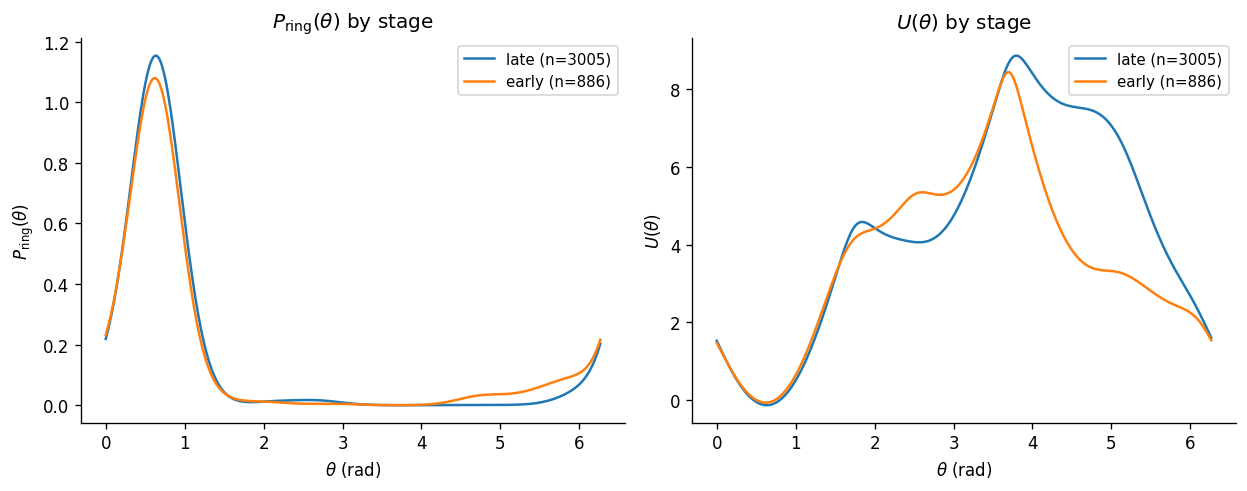

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_density_potential_by_week.png


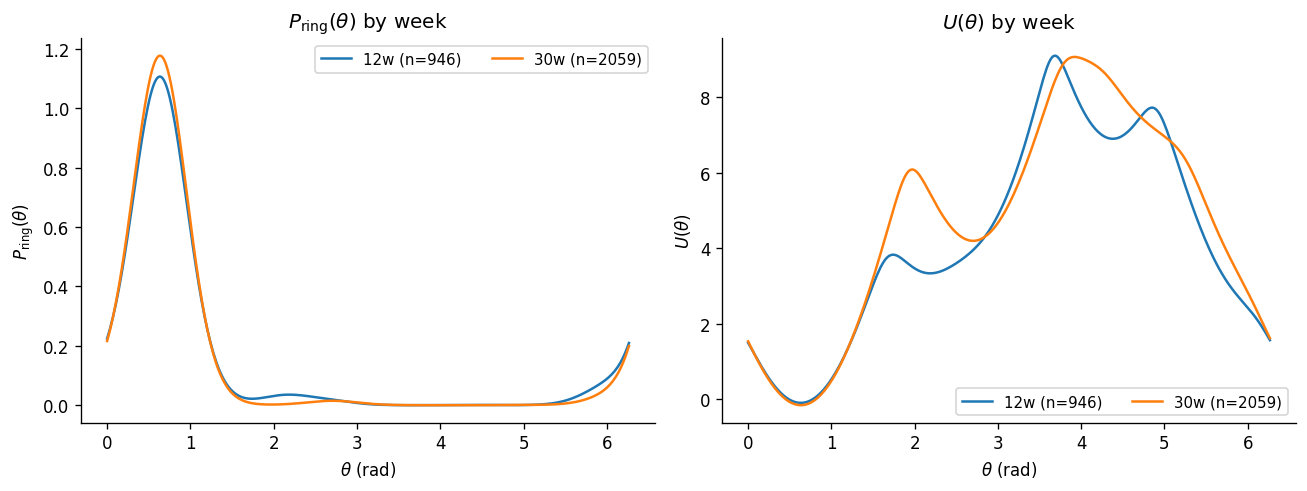

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_barriers_by_group.csv


,group,n,barrier1,barrier2
0,stage:late,3005,4.812716,0.525234
1,stage:early,886,3.165346,0.066903
2,week:12,946,2.204439,0.826132
3,week:30,2059,4.878006,1.893039


In [14]:
# --- Cell 14: by-group landscapes (stage & week) + barrier tables ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import argrelextrema

# Helpers (use globals: theta_grid, kappa, gamma, r_star, sigma_ring)
def vm_pdf(d, kappa):
    from scipy.special import i0
    return np.exp(kappa*np.cos(d)) / (2*np.pi*i0(kappa))

def ring_density_scan(theta, radius, p, kappa, gamma, r_star, sigma, grid):
    ann = np.exp(-0.5*((radius - r_star)/(sigma+1e-12))**2)
    w   = (np.clip(p,0,1)**gamma) * ann + 1e-12
    d   = grid[:,None] - theta[None,:]
    Pθ  = (vm_pdf(d, kappa) * w[None,:]).sum(axis=1)
    Pθ  = Pθ / (np.trapezoid(Pθ, grid) + 1e-12)
    return Pθ, -np.log(Pθ + 1e-12)

def barrier_heights_full(U):
    pad = np.r_[U[-1], U, U[0]]
    idx_max = argrelextrema(pad, np.greater)[0] - 1
    idx_min = argrelextrema(pad, np.less   )[0] - 1
    idx_max = idx_max[(idx_max>=0)&(idx_max<len(U))]
    idx_min = idx_min[(idx_min>=0)&(idx_min<len(U))]
    out = []
    for imax in idx_max:
        left  = idx_min[idx_min < imax];  left  = left[-1] if left.size else idx_min[-1]
        right = idx_min[idx_min > imax];  right = right[0] if right.size else idx_min[0]
        out.append(dict(
            idx=int(imax),
            theta=float(theta_grid[imax]),
            U=float(U[imax]),
            height=float(U[imax] - max(U[left], U[right]))
        ))
    out.sort(key=lambda d: d["height"], reverse=True)
    return out

def compute_group_landscape(mask_bool_np, label):
    th = theta[mask_bool_np]; rad = radius[mask_bool_np]; pp = p[mask_bool_np]
    if th.size < 100:
        return None  # too few cells for a stable curve
    Pg, Ug = ring_density_scan(th, rad, pp, float(kappa), float(gamma), r_star, sigma_ring, theta_grid)
    bars = barrier_heights_full(Ug)
    top2 = bars[:2] if bars else []
    rec = dict(group=str(label), n=int(th.size),
               barrier1=top2[0]["height"] if len(top2)>0 else np.nan,
               barrier2=top2[1]["height"] if len(top2)>1 else np.nan)
    return Pg, Ug, rec

group_rows = []

# ----- stage_label -----
if "stage_label" in adata.obs:
    labels = adata.obs["stage_label"].astype("string")
    uniq = [u for u in labels.dropna().unique()]
    fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.2))
    for u in uniq:
        mask = (labels == u).fillna(False).to_numpy()
        out = compute_group_landscape(mask, f"stage:{u}")
        if out:
            Pg, Ug, rec = out
            ax[0].plot(theta_grid, Pg, label=f"{u} (n={rec['n']})")
            ax[1].plot(theta_grid, Ug, label=f"{u} (n={rec['n']})")
            group_rows.append(rec)
    ax[0].set_title(r"$P_{\mathrm{ring}}(\theta)$ by stage"); ax[0].set_ylabel(r"$P_{\mathrm{ring}}(\theta)$")
    ax[1].set_title(r"$U(\theta)$ by stage");            ax[1].set_ylabel(r"$U(\theta)$")
    for a in ax: a.set_xlabel(r"$\theta$ (rad)")
    ax[0].legend(fontsize=9); ax[1].legend(fontsize=9)
    savefig("fig04_density_potential_by_stage.png"); plt.show()

# ----- week (ordered, skip tiny groups) -----
if "week" in adata.obs:
    w = adata.obs["week"].astype("Int64")
    order = [int(x) for x in sorted(w.dropna().unique())]
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 4.2))
    for u in order:
        mask = (w == u).fillna(False).to_numpy()   # <-- fix: pure boolean NumPy mask
        if mask.sum() < 200:
            continue
        out = compute_group_landscape(mask, f"week:{u}")
        if out:
            Pg, Ug, rec = out
            ax[0].plot(theta_grid, Pg, label=f"{u}w (n={rec['n']})")
            ax[1].plot(theta_grid, Ug, label=f"{u}w (n={rec['n']})")
            group_rows.append(rec)
    ax[0].set_title(r"$P_{\mathrm{ring}}(\theta)$ by week"); ax[0].set_ylabel(r"$P_{\mathrm{ring}}(\theta)$")
    ax[1].set_title(r"$U(\theta)$ by week");                ax[1].set_ylabel(r"$U(\theta)$")
    for a in ax: a.set_xlabel(r"$\theta$ (rad)")
    ax[0].legend(ncol=3, fontsize=9); ax[1].legend(ncol=3, fontsize=9)
    savefig("fig04_density_potential_by_week.png"); plt.show()

tab_groups = pd.DataFrame(group_rows)
tab_groups.to_csv(TABDIR / "tab04_barriers_by_group.csv", index=False)
print("[saved]", TABDIR / "tab04_barriers_by_group.csv")
display(tab_groups.head())

## 15) Interpolate $U(\theta)$ and $\tilde v(\theta)$ to per-cell obs

Attach the ring landscape to each cell so you can color embeddings later without re-running 04.

[write] added obs['U_theta'], obs['vtilde_theta'] → /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_x_phate_U_theta.png


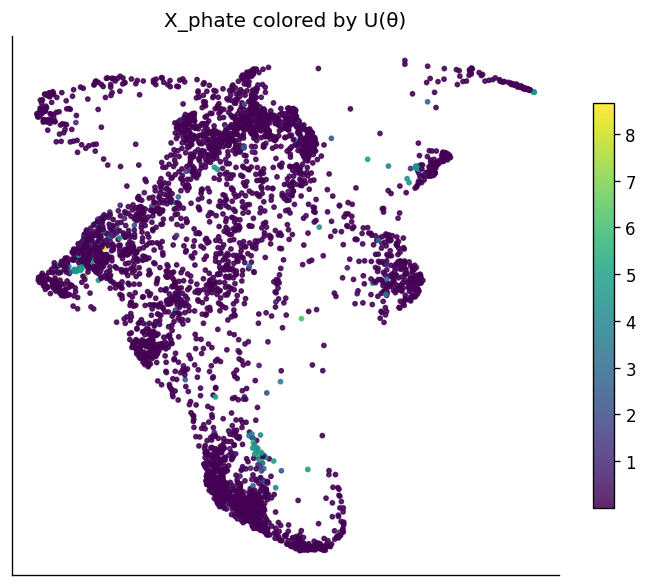

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_x_phate_vtilde_theta.png


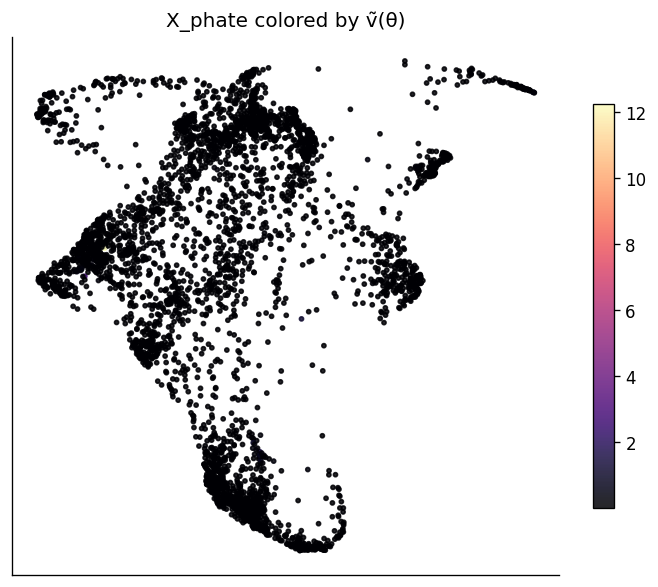

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_x_tsne_U_theta.png


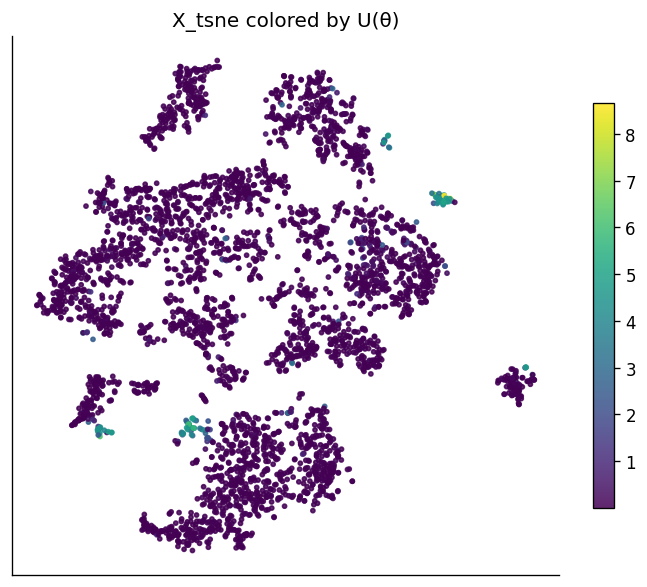

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_x_tsne_vtilde_theta.png


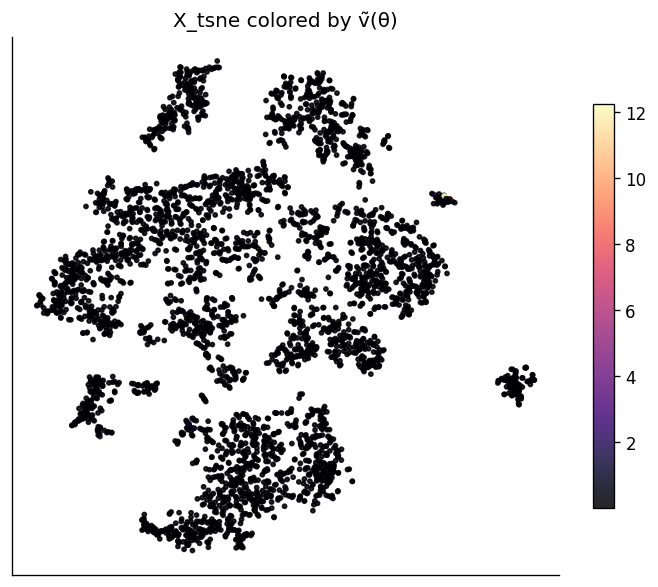

In [15]:
# --- Cell 15: interpolate U(θ) and ṽ(θ) onto cells and persist ---
import numpy as np
from scipy.interpolate import interp1d

def periodic_interp(x_grid, y_grid, x_query):
    xg = np.r_[x_grid, x_grid[0] + 2*np.pi]
    yg = np.r_[y_grid, y_grid[0]]
    xq = np.mod(x_query, 2*np.pi)
    f  = interp1d(xg, yg, kind="linear", assume_sorted=True)
    return f(xq)

adata.obs["U_theta"]      = periodic_interp(theta_grid, U,       adata.obs["theta"].to_numpy().astype(float))
adata.obs["vtilde_theta"] = periodic_interp(theta_grid, v_tilde, adata.obs["theta"].to_numpy().astype(float))
adata.write(ANNDATA)
print("[write] added obs['U_theta'], obs['vtilde_theta'] →", ANNDATA)

# Optional quick plots on authors' embeddings
for emb in ("X_phate","X_tsne"):
    if emb in adata.obsm:
        M = adata.obsm[emb]
        for col, cmap, title in [("U_theta","viridis","U(θ)"), ("vtilde_theta","magma","ṽ(θ)")]:
            plt.figure(figsize=(6,5))
            sc = plt.scatter(M[:,0], M[:,1], s=6, c=adata.obs[col].to_numpy(), cmap=cmap, alpha=0.85)
            plt.xticks([]); plt.yticks([]); plt.title(f"{emb} colored by {title}")
            plt.colorbar(sc, shrink=0.75)
            savefig(f"fig04_{emb.lower()}_{col}.png"); plt.show()

## 16) Group-to-group distance on the ring (rotation-invariant circular (W_1))

Compute the Wasserstein-1 distance between **phase densities** of groups (using the same $\kappa,\gamma,\tau$ already chosen). We use the “cut trick” (min over circular shifts) so distances are **rotation-invariant** on the circle. Export a heatmap and a table for Notebook 05.

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_group_circW1.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_group_circW1_heatmap.png


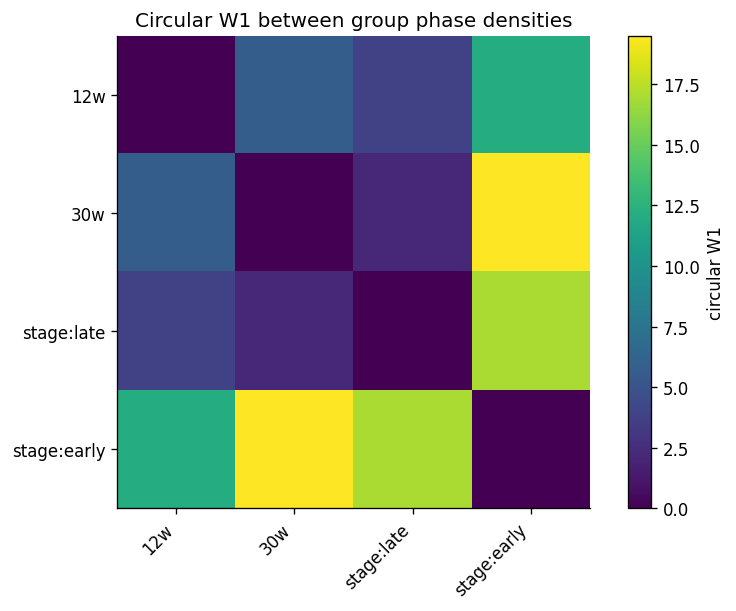

In [16]:
# --- Cell 16: rotation-invariant circular W1 between group densities ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt

MIN_N = 200  # skip groups smaller than this

def w1_line(p, q, dtheta):
    # 1D W1 on a line for histograms on the same grid
    cum = np.cumsum(p - q)
    return float(dtheta * np.sum(np.abs(cum)))

def w1_circular(p, q):
    # min over all circular shifts ("cut trick")
    dθ = 2*np.pi / len(p)
    best = np.inf
    for s in range(len(p)):
        q_roll = np.roll(q, s)
        best = min(best, w1_line(p, q_roll, dθ))
    return best

def group_density(mask_bool_np):
    th = theta[mask_bool_np]; rad = radius[mask_bool_np]; pp = p[mask_bool_np]
    if th.size < MIN_N:
        return None
    Pθ, _ = ring_density_scan(th, rad, pp, float(kappa), float(gamma), r_star, sigma_ring, theta_grid)
    # ring_density_scan already normalizes; keep as-is
    return Pθ

groups, dens = [], []

# Week groups (ordered)
if "week" in adata.obs:
    w = adata.obs["week"].astype("Int64")
    order = [int(x) for x in sorted(w.dropna().unique())]
    for u in order:
        m = (w == u).fillna(False).to_numpy()   # <-- ensure pure boolean NumPy mask
        Pθ = group_density(m)
        if Pθ is not None:
            groups.append(f"{u}w")
            dens.append(Pθ)

# Stage groups (early/late)
if "stage_label" in adata.obs:
    s = adata.obs["stage_label"].astype("string")
    for u in [x for x in s.dropna().unique()]:
        m = (s == u).fillna(False).to_numpy()
        Pθ = group_density(m)
        if Pθ is not None:
            groups.append(f"stage:{u}")
            dens.append(Pθ)

assert len(dens) > 0, "No groups with sufficient cells to compute W1."

# Pairwise circular W1 matrix
G = len(dens)
D = np.zeros((G, G), float)
for i in range(G):
    for j in range(i+1, G):
        dij = w1_circular(dens[i], dens[j])
        D[i, j] = D[j, i] = dij

dfW = pd.DataFrame(D, index=groups, columns=groups)
dfW.to_csv(TABDIR/"tab04_group_circW1.csv")
print("[saved]", TABDIR/"tab04_group_circW1.csv")

plt.figure(figsize=(6.8, 5.2))
im = plt.imshow(D, cmap="viridis")
plt.colorbar(im, label="circular W1")
plt.xticks(range(G), groups, rotation=45, ha="right")
plt.yticks(range(G), groups)
plt.title("Circular W1 between group phase densities")
plt.tight_layout(); savefig("fig04_group_circW1_heatmap.png"); plt.show()

# (optional) persist into uns for 05
adata.uns.setdefault("landscape", {})
adata.uns["landscape"]["group_circW1"] = {
    "groups": groups,
    "matrix": D.tolist(),
    "min_n": int(MIN_N)
}
adata.write(ANNDATA)

## 17) Bootstrap CIs for circular (W_1) between groups

We resample cells **within each group** (B) times, recompute each group’s ring density with the same $\kappa,\gamma,\tau$, and take the **rotation-invariant** circular (W_1) between all pairs. Outputs:

* `tab04_group_circW1_bootstrap.csv` (pairwise baseline, median, 95% CI)
* `fig04_group_circW1_bootstrap_heatmap.png` (median (W_1); baseline values overlaid)
* `adata.uns["landscape"]["group_circW1_boot"]` (provenance)


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_group_circW1_bootstrap.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_group_circW1_bootstrap_heatmap.png


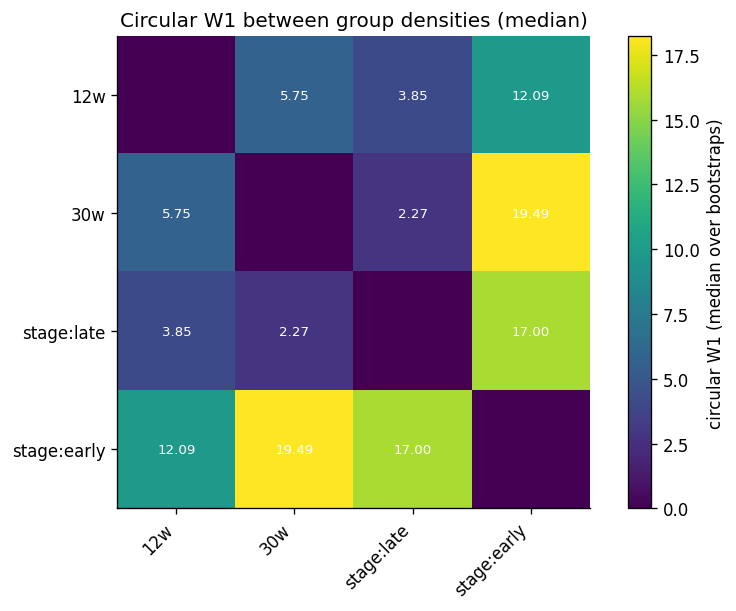

In [17]:
# --- Cell 17: bootstrap CIs for circular W1 between groups ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt

MIN_N = 200     # skip groups smaller than this
B = 200         # number of bootstrap resamples (adjust if needed)

rng = np.random.default_rng(int(P["model"].get("seed", 42)) + 1701)

# --- helpers (defensively redefined here) ---
from scipy.special import i0
def vm_pdf(d, kappa):
    return np.exp(kappa*np.cos(d)) / (2*np.pi*i0(kappa))

def ring_density_scan(theta, radius, p, kappa, gamma, r_star, sigma, grid):
    ann = np.exp(-0.5*((radius - r_star)/(sigma+1e-12))**2)
    w   = (np.clip(p,0,1)**gamma) * ann + 1e-12
    d   = grid[:,None] - theta[None,:]
    Pθ  = (vm_pdf(d, kappa) * w[None,:]).sum(axis=1)
    Pθ  = Pθ / (np.trapezoid(Pθ, grid) + 1e-12)
    return Pθ, -np.log(Pθ + 1e-12)

def w1_line(p, q, dtheta):
    cum = np.cumsum(p - q)
    return float(dtheta * np.sum(np.abs(cum)))

def w1_circular(p, q):
    dθ = 2*np.pi / len(p)
    best = np.inf
    for s in range(len(p)):
        q_roll = np.roll(q, s)
        best = min(best, w1_line(p, q_roll, dθ))
    return best

def pairwise_circW1(dens_list):
    G = len(dens_list)
    M = np.zeros((G, G), float)
    for i in range(G):
        for j in range(i+1, G):
            dij = w1_circular(dens_list[i], dens_list[j])
            M[i,j] = M[j,i] = dij
    return M

# --- build groups (weeks, then stages) ---
groups, indices = [], []

if "week" in adata.obs:
    w = adata.obs["week"].astype("Int64")
    for u in sorted([int(x) for x in w.dropna().unique()]):
        mask = (w == u).fillna(False).to_numpy()
        idx  = np.where(mask)[0]
        if idx.size >= MIN_N:
            groups.append(f"{u}w"); indices.append(idx)

if "stage_label" in adata.obs:
    s = adata.obs["stage_label"].astype("string")
    for u in [x for x in s.dropna().unique()]:
        mask = (s == u).fillna(False).to_numpy()
        idx  = np.where(mask)[0]
        if idx.size >= MIN_N:
            groups.append(f"stage:{u}"); indices.append(idx)

assert groups, "No groups with ≥ MIN_N cells."

# --- baseline densities & distances ---
dens_baseline = []
for idx in indices:
    th = theta[idx]; rad = radius[idx]; pp = p[idx]
    Pθ, _ = ring_density_scan(th, rad, pp, float(kappa), float(gamma), r_star, sigma_ring, theta_grid)
    dens_baseline.append(Pθ)

D0 = pairwise_circW1(dens_baseline)   # baseline W1

# --- bootstrap ---
Gnum = len(groups)
boot_vals = np.zeros((B, Gnum, Gnum), float)

for b in range(B):
    dens_b = []
    for idx in indices:
        idx_b = rng.choice(idx, size=idx.size, replace=True)
        th = theta[idx_b]; rad = radius[idx_b]; pp = p[idx_b]
        Pθ, _ = ring_density_scan(th, rad, pp, float(kappa), float(gamma), r_star, sigma_ring, theta_grid)
        dens_b.append(Pθ)
    boot_vals[b] = pairwise_circW1(dens_b)

# --- summarize ---
qlo, qmed, qhi = np.quantile(boot_vals, [0.025, 0.5, 0.975], axis=0)

rows = []
for i in range(Gnum):
    for j in range(i+1, Gnum):
        rows.append({
            "group_i": groups[i], "group_j": groups[j],
            "W1_baseline": D0[i,j],
            "W1_q2.5":    qlo[i,j],
            "W1_median":  qmed[i,j],
            "W1_q97.5":   qhi[i,j],
        })
df_ci = pd.DataFrame(rows).sort_values(["group_i", "group_j"])
df_ci.to_csv(TABDIR/"tab04_group_circW1_bootstrap.csv", index=False)
print("[saved]", TABDIR/"tab04_group_circW1_bootstrap.csv")

# Heatmap of median W1; baseline numbers annotated
plt.figure(figsize=(6.8, 5.2))
im = plt.imshow(qmed, cmap="viridis")
plt.colorbar(im, label="circular W1 (median over bootstraps)")
plt.xticks(range(Gnum), groups, rotation=45, ha="right")
plt.yticks(range(Gnum), groups)
plt.title("Circular W1 between group densities (median)")
for i in range(Gnum):
    for j in range(Gnum):
        if i == j: continue
        plt.text(j, i, f"{D0[i,j]:.2f}", ha="center", va="center", color="w", fontsize=8)
plt.tight_layout(); savefig("fig04_group_circW1_bootstrap_heatmap.png"); plt.show()

# persist in uns
adata.uns.setdefault("landscape", {})
adata.uns["landscape"]["group_circW1_boot"] = {
    "groups": groups,
    "B": int(B),
    "min_n": int(MIN_N),
    "baseline": D0.tolist(),
    "q2.5": qlo.tolist(),
    "median": qmed.tolist(),
    "q97.5": qhi.tolist(),
}
adata.write(ANNDATA)


### 18) Focused contrasts: circular (W_1) (median $\pm$ 95% CI) for key pairs

Bar chart of **pairwise** rotation-invariant circular (W_1) between selected groups with bootstrap CIs (from Cell 17). Defaults:

* **Stage:** `stage:early` vs `stage:late` (if both exist)
* **Weeks:** consecutive pairs (e.g., `2w–12w`, `12w–30w`) and the **extreme** span (e.g., `2w–30w`) if present

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_focus_W1_contrasts.csv


,pair,group_i,group_j,W1_baseline,W1_median,W1_q2.5,W1_q97.5
0,early–late,stage:early,stage:late,17.002538,15.930323,2.368193,30.755607
1,12w–30w,12w,30w,5.747814,5.723668,1.779805,10.743823


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_focus_W1_contrasts.png


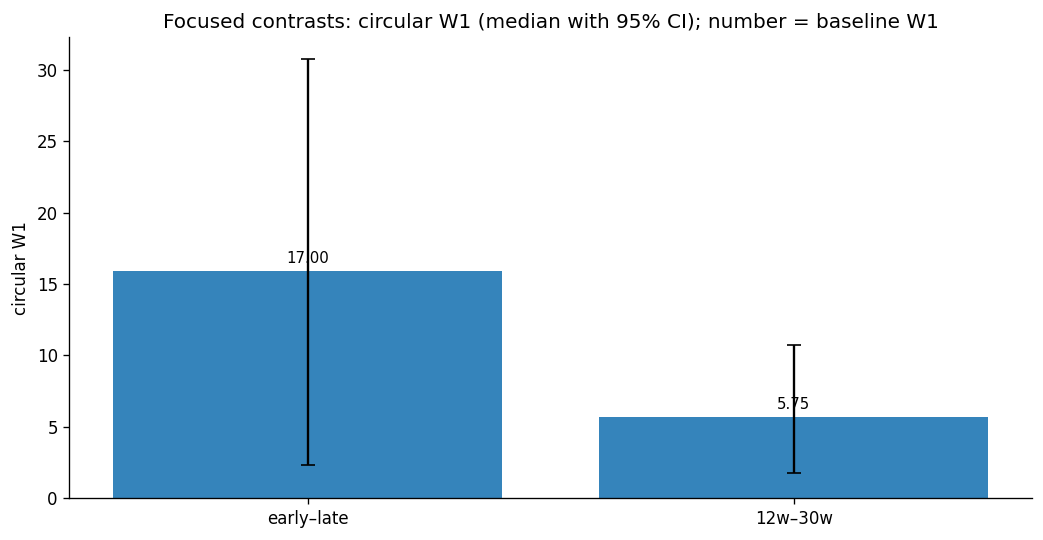

In [18]:
# --- Cell 18: focused W1 contrasts (bar chart with 95% CIs) ---
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt

ci_path = TABDIR / "tab04_group_circW1_bootstrap.csv"
df = pd.read_csv(ci_path)
assert not df.empty, "Bootstrap CI table not found or empty—run Cell 17 first."

def get_pair_row(df, a, b):
    r = df[(df["group_i"]==a) & (df["group_j"]==b)]
    if r.empty:
        r = df[(df["group_i"]==b) & (df["group_j"]==a)]
    return r

# Build a list of groups present anywhere in the table
present = set(pd.concat([df["group_i"], df["group_j"]]).unique())

# 1) Stage contrast (if available)
contrasts = []
label_map = {}  # for pretty pair labels

if "stage:early" in present and "stage:late" in present:
    r = get_pair_row(df, "stage:early", "stage:late")
    if not r.empty:
        contrasts.append(("stage:early", "stage:late"))
        label_map[("stage:early", "stage:late")] = "early–late"

# 2) Week contrasts (consecutive + extremes if available)
weeks = sorted([
    int(m.group(1)) for g in present
    if (m := re.match(r"^(\d+)w$", g))
])

for a, b in zip(weeks[:-1], weeks[1:]):  # consecutive pairs
    ga, gb = f"{a}w", f"{b}w"
    r = get_pair_row(df, ga, gb)
    if not r.empty:
        contrasts.append((ga, gb))
        label_map[(ga, gb)] = f"{a}w–{b}w"

# extremes (first vs last), if both present and distinct from consecutive-only set
if len(weeks) >= 2:
    ga, gb = f"{weeks[0]}w", f"{weeks[-1]}w"
    r = get_pair_row(df, ga, gb)
    if not r.empty and (ga, gb) not in contrasts and (gb, ga) not in contrasts:
        contrasts.append((ga, gb))
        label_map[(ga, gb)] = f"{weeks[0]}w–{weeks[-1]}w"

# Build tidy table of selected contrasts
rows = []
for a, b in contrasts:
    r = get_pair_row(df, a, b)
    if r.empty:
        continue
    r = r.iloc[0]
    rows.append({
        "pair": label_map.get((a,b), f"{a}–{b}"),
        "group_i": a, "group_j": b,
        "W1_baseline": float(r["W1_baseline"]),
        "W1_median":   float(r["W1_median"]),
        "W1_q2.5":     float(r["W1_q2.5"]),
        "W1_q97.5":    float(r["W1_q97.5"]),
    })

assert rows, "No valid contrasts found—check group names or MIN_N in Cell 17."

focus = pd.DataFrame(rows).sort_values("W1_median", ascending=False)
focus_path = TABDIR / "tab04_focus_W1_contrasts.csv"
focus.to_csv(focus_path, index=False)
print("[saved]", focus_path)
display(focus)

# Plot
x = np.arange(len(focus))
y = focus["W1_median"].to_numpy()
yerr = np.vstack([y - focus["W1_q2.5"].to_numpy(),
                  focus["W1_q97.5"].to_numpy() - y])

plt.figure(figsize=(8.8, 4.6))
bars = plt.bar(x, y, alpha=0.9)
plt.errorbar(x, y, yerr=yerr, fmt="none", lw=1.4, capsize=4, color="black")

# annotate baseline (from non-bootstrapped W1) on each bar
for i, (bx, by, base) in enumerate(zip(x, y, focus["W1_baseline"].to_numpy())):
    plt.text(bx, by + 0.02*np.max(y), f"{base:.2f}", ha="center", va="bottom", fontsize=9)

plt.xticks(x, focus["pair"].tolist(), rotation=0)
plt.ylabel("circular W1")
plt.title("Focused contrasts: circular W1 (median with 95% CI); number = baseline W1")
plt.tight_layout(); savefig("fig04_focus_W1_contrasts.png"); plt.show()



## 19) Approximate ring flux (J) and speed $\tilde v(\theta)$ from $\rho(\theta)$ and $U(\theta)$

**Idea (Li–Wang steady state on the ring).** On a 1D periodic ring, the Fokker–Planck steady state implies
$$
J(\theta);=;\mu,\rho(\theta),f(\theta);-;D,\partial_\theta \rho(\theta)
\quad\text{with}\quad f(\theta)=-U'(\theta),
$$
and the **current $J(\theta)$ should be (approximately) constant** if the flux picture is self-consistent. We fit a **weighted least squares** relation
$$
\partial_\theta \rho \approx \lambda,\rho,f + \beta\quad(\lambda=\mu/D)!,
$$
so that $J(\theta)=\lambda\rho f-\partial_\theta\rho \approx -\beta$ (constant). Then define a **relative speed**
$$
\tilde v(\theta)=\frac{\widehat J}{\rho(\theta)}\quad(\text{unitless, mean unconstrained}).
$$


[flux] λ=μ/D ≈ 0.9992 | Ĵ ≈ -0.0001 (arb.)
[flux] var(J(θ))=2.846e-07,  CV(J)=1.896
[flux] corr( ṽ_from_1/ρ , ṽ_from_flux ) = -1.000
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_flux_current_and_speed.png


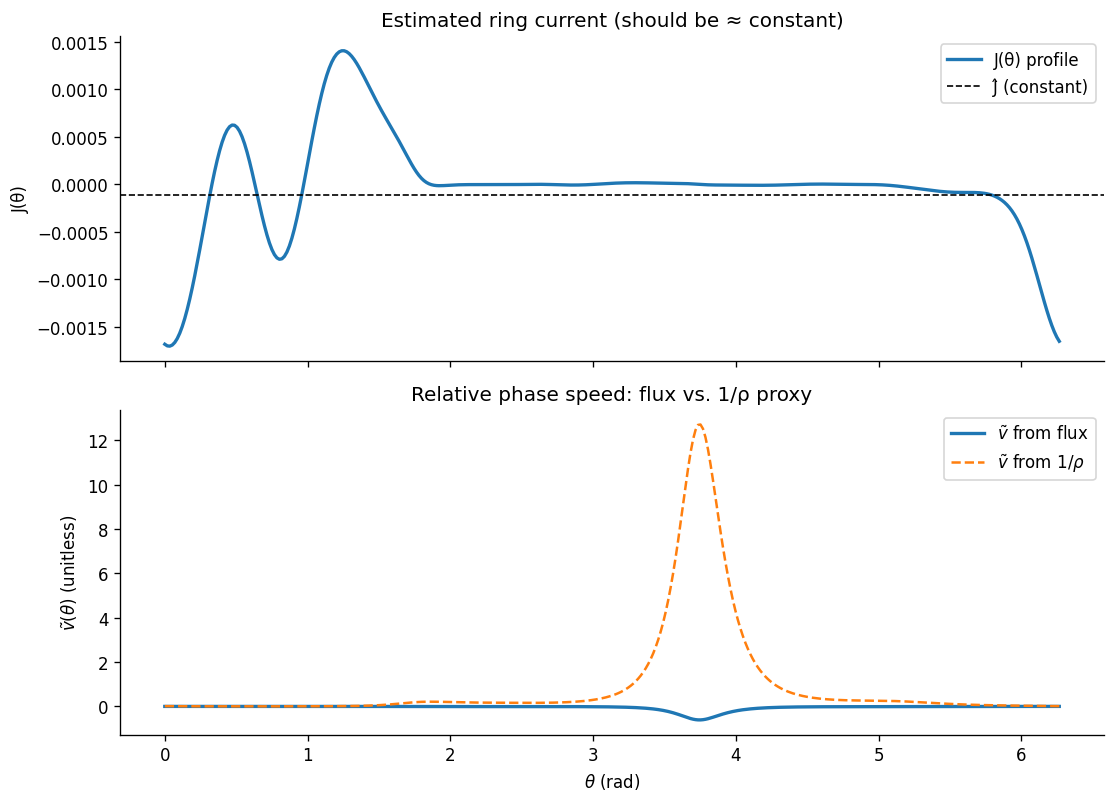

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_flux_summary.csv
[write] updated with flux estimates → /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad


In [19]:
# --- Cell 19: ring flux & speed from (ρ, U) ---
import numpy as np
import matplotlib.pyplot as plt

# Reuse: theta_grid, P_ring (ρ), U, savefig(), adata, ANNDATA already exist
rho = P_ring.copy()
Uth = U.copy()

# Periodic central derivative
dθ = float(theta_grid[1] - theta_grid[0])
def circ_grad(y):
    return (np.roll(y, -1) - np.roll(y, 1)) / (2.0 * dθ)

# Drift and density gradient
fθ   = -circ_grad(Uth)      # f = -U'
drho =  circ_grad(rho)

# Weighted least squares:  drho ≈ λ * (rho * fθ) + β
A = rho * fθ
B = drho
w = rho / (rho.mean() + 1e-12)          # emphasize regions with data
X = np.c_[A, np.ones_like(A)]
W = np.sqrt(np.clip(w, 1e-8, None))
coef, *_ = np.linalg.lstsq(X * W[:, None], B * W, rcond=None)
lam_hat, beta_hat = coef
J_hat = float(-beta_hat)                 # constant current estimate
J_profile = lam_hat * A - B              # should be ~ constant
v_from_flux = J_hat / (rho + 1e-12)      # relative speed from flux

# Compare to earlier proxy ṽ = 1/ρ (already computed as v_tilde)
corr = np.corrcoef(v_tilde, v_from_flux)[0,1]
cvJ  = np.std(J_profile) / (np.mean(np.abs(J_profile)) + 1e-12)

print(f"[flux] λ=μ/D ≈ {lam_hat:.4f} | Ĵ ≈ {J_hat:.4f} (arb.)")
print(f"[flux] var(J(θ))={np.var(J_profile):.3e},  CV(J)={cvJ:.3f}")
print(f"[flux] corr( ṽ_from_1/ρ , ṽ_from_flux ) = {corr:.3f}")

# Plots
fig, axs = plt.subplots(2, 1, figsize=(9.4, 6.8), sharex=True)
axs[0].plot(theta_grid, J_profile, lw=2, label="J(θ) profile")
axs[0].axhline(J_hat, ls="--", c="k", lw=1, label="Ĵ (constant)")
axs[0].set_ylabel("J(θ)")
axs[0].set_title("Estimated ring current (should be ≈ constant)")
axs[0].legend()

axs[1].plot(theta_grid, v_from_flux, lw=2, label=r"$\tilde v$ from flux")
axs[1].plot(theta_grid, v_tilde, ls="--", lw=1.5, label=r"$\tilde v$ from $1/\rho$")
axs[1].set_xlabel(r"$\theta$ (rad)")
axs[1].set_ylabel(r"$\tilde v(\theta)$ (unitless)")
axs[1].set_title("Relative phase speed: flux vs. 1/ρ proxy")
axs[1].legend()

savefig("fig04_flux_current_and_speed.png"); plt.show()

# Persist small summary
import pandas as pd
pd.DataFrame([{
    "lambda_mu_over_D": float(lam_hat),
    "J_hat": float(J_hat),
    "var_J": float(np.var(J_profile)),
    "cv_J": float(cvJ),
    "corr_vtilde_flux_vs_invRho": float(corr),
}]).to_csv(TABDIR/"tab04_flux_summary.csv", index=False)
print("[saved]", TABDIR/"tab04_flux_summary.csv")

adata.uns.setdefault("landscape_ring", {})
adata.uns["landscape_ring"].update({
    "lambda_mu_over_D": float(lam_hat),
    "J_hat": float(J_hat),
    "theta_grid": theta_grid.tolist(),
    "rho_theta": rho.tolist(),
    "U_theta": Uth.tolist(),
    "vtilde_from_flux": v_from_flux.tolist(),
    "vtilde_from_invRho": v_tilde.tolist(),
    "cv_J": float(cvJ),
    "corr_vtilde_flux_vs_invRho": float(corr),
})
adata.write(ANNDATA)
print("[write] updated with flux estimates →", ANNDATA)

## 20) Flux diagnostics & per-group current (early/late, 12w/30w)

This gives you a compact QC table + a small group comparison (same $\kappa,\gamma,\tau$; **no re-CV**).

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_flux_by_group.csv


,J_hat,cv_J,group,n
2,-0.000098,1.912385,12w,946
3,-0.000105,1.857511,30w,2059
1,-0.000143,1.943171,stage:early,886
0,-0.000105,1.884711,stage:late,3005


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_flux_by_group.png


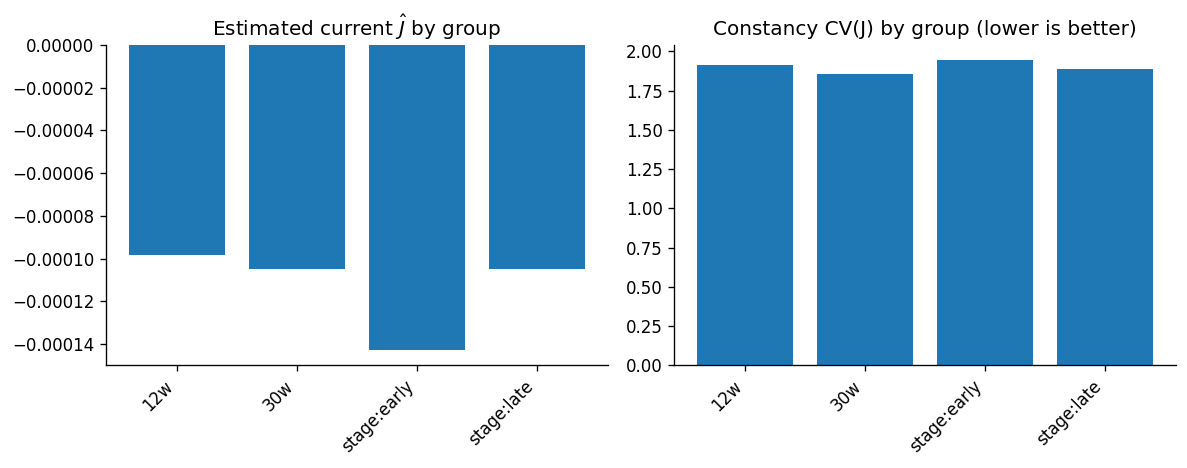

In [20]:
# --- Cell 20 (fixed): flux QC by group (handles pandas <NA> in masks) ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def _to_bool_mask(mask):
    # Accept pandas Series/BooleanArray/Index or numpy array
    if isinstance(mask, (pd.Series, pd.Index)):
        return mask.fillna(False).to_numpy(dtype=bool)
    # pandas BooleanArray (equality ops can return this)
    try:
        import pandas as _pd
        if isinstance(mask, _pd.arrays.BooleanArray):
            return mask.fillna(False).to_numpy(dtype=bool)
    except Exception:
        pass
    # fallback
    m = np.asarray(mask)
    if m.dtype.kind in {"f", "O"}:
        # defensive: treat NaN/None as False
        m = np.where(pd.isna(m), False, m).astype(bool)
    else:
        m = m.astype(bool)
    return m

def flux_from_group(mask):
    m = _to_bool_mask(mask)
    th = theta[m]; rad = radius[m]; pp = p[m]
    if th.size < 100:
        return None
    Pg, Ug = cc.ring_density_and_potential(
        theta_grid=theta_grid,
        theta=th, radius=rad,
        weights=np.power(np.clip(pp,0,1), gamma),
        kappa=float(kappa), r_star=float(r_star), tau=float(tau), h_r=None
    )
    Pg = Pg / (np.trapezoid(Pg, theta_grid) + 1e-12); Ug -= Ug.min()

    dθ   = float(theta_grid[1]-theta_grid[0])
    grad = lambda y: (np.roll(y,-1)-np.roll(y,1))/(2*dθ)
    fθ, dr = -grad(Ug), grad(Pg)

    A, B = Pg*fθ, dr
    w    = Pg/(Pg.mean()+1e-12)
    X    = np.c_[A, np.ones_like(A)]; W = np.sqrt(np.clip(w,1e-8,None))
    lam, beta = np.linalg.lstsq(X*W[:,None], B*W, rcond=None)[0]
    Jhat = -beta
    Jprof= lam*A - B
    cvJ  = np.std(Jprof) / (np.mean(np.abs(Jprof)) + 1e-12)
    return dict(J_hat=float(Jhat), cv_J=float(cvJ)), (Pg, Ug)

rows = []

# stage_label groups
if "stage_label" in adata.obs:
    s = adata.obs["stage_label"].astype("string")
    for g in [x for x in s.dropna().unique()]:
        out = flux_from_group(s == g)
        if out:
            row, _ = out
            row.update(group=f"stage:{g}", n=int((s == g).sum()))
            rows.append(row)

# week groups (skip tiny)
if "week" in adata.obs:
    w = adata.obs["week"].astype("Int64")
    for g in sorted([int(x) for x in w.dropna().unique()]):
        m = (w == g)
        if int(m.sum()) >= 200:
            out = flux_from_group(m)
            if out:
                row, _ = out
                row.update(group=f"{g}w", n=int(m.sum()))
                rows.append(row)

dfJ = pd.DataFrame(rows).sort_values("group")
dfJ.to_csv(TABDIR/"tab04_flux_by_group.csv", index=False)
print("[saved]", TABDIR/"tab04_flux_by_group.csv")
display(dfJ)

# quick plot
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].bar(range(len(dfJ)), dfJ["J_hat"]); ax[0].set_title(r"Estimated current $\hat{J}$ by group")
ax[0].set_xticks(range(len(dfJ))); ax[0].set_xticklabels(dfJ["group"], rotation=45, ha="right")
ax[1].bar(range(len(dfJ)), dfJ["cv_J"]);  ax[1].set_title("Constancy CV(J) by group (lower is better)")
ax[1].set_xticks(range(len(dfJ))); ax[1].set_xticklabels(dfJ["group"], rotation=45, ha="right")
plt.tight_layout(); savefig("fig04_flux_by_group.png"); plt.show()


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_speed_compare.png


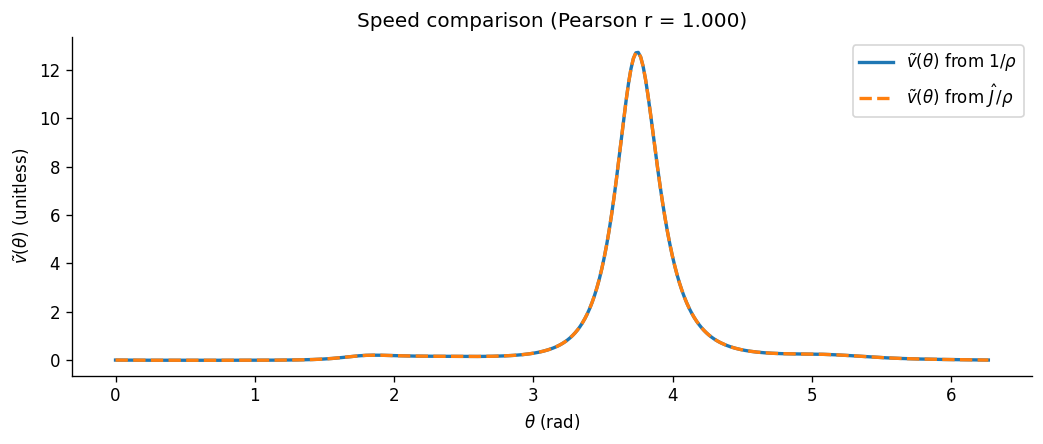

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_speed_compare.png


In [21]:
import numpy as np, matplotlib.pyplot as plt
from scipy.stats import pearsonr

rho = P_ring.copy()              # from earlier cells
dθ  = float(theta_grid[1]-theta_grid[0])

# Baseline speed proxy from density only (already used earlier)
inv = 1.0 / np.clip(rho, 1e-9, None)
v_from_rho = inv / (inv.mean() + 1e-12)

# Speed from estimated current (sign-invariant by |Ĵ|)
J_abs = abs(adata.uns.get("landscape_ring", {}).get("J_hat", 0.0))
v_from_J = (J_abs / np.clip(rho, 1e-9, None))
v_from_J = v_from_J / (v_from_J.mean() + 1e-12)

r_val, _ = pearsonr(v_from_rho, v_from_J)

fig, ax = plt.subplots(1,1, figsize=(8.8,3.8))
ax.plot(theta_grid, v_from_rho,  lw=2, label=r"$\tilde v(\theta)$ from $1/\rho$")
ax.plot(theta_grid, v_from_J,    lw=2, ls="--", label=r"$\tilde v(\theta)$ from $\hat J/\rho$")
ax.set_xlabel(r"$\theta$ (rad)"); ax.set_ylabel(r"$\tilde v(\theta)$ (unitless)")
ax.set_title(fr"Speed comparison (Pearson r = {r_val:.3f})")
ax.legend()
savefig("fig04_speed_compare.png"); plt.show()

# persist quick sanity summary
adata.uns.setdefault("landscape_ring", {})
adata.uns["landscape_ring"]["speed_compare_r"] = float(r_val)
adata.write(ANNDATA)
print("[saved]", FIGDIR/"fig04_speed_compare.png")


In [22]:
import numpy as np, pandas as pd

def vm_pdf(d, kappa):
    from scipy.special import i0
    return np.exp(kappa*np.cos(d)) / (2*np.pi*i0(kappa))

def ring_density_scan(theta, radius, p, kappa, gamma, r_star, sigma, grid):
    ann = np.exp(-0.5*((radius - r_star)/(sigma+1e-12))**2)
    w   = (np.clip(p,0,1)**gamma) * ann + 1e-12
    d   = grid[:,None] - theta[None,:]
    Pθ  = (vm_pdf(d, kappa) * w[None,:]).sum(axis=1)
    Pθ  = Pθ / (np.trapezoid(Pθ, grid) + 1e-12)
    return Pθ, -np.log(Pθ + 1e-12)

# Pull the barrier and flux tables we already wrote
bar_path = TABDIR/"tab04_barriers_by_group.csv"
flux_path= TABDIR/"tab04_flux_by_group.csv"
bars  = pd.read_csv(bar_path) if bar_path.exists() else pd.DataFrame()
flux  = pd.read_csv(flux_path) if flux_path.exists() else pd.DataFrame()

def summarize_groups(group_key, min_n=200):
    out = []
    if group_key not in adata.obs:
        return pd.DataFrame()
    gser = adata.obs[group_key]
    if str(gser.dtype) == "Int64":
        labels = [str(int(x))+"w" if group_key=="week" else str(int(x)) for x in sorted(gser.dropna().unique())]
        masks  = [(gser == int(lbl.replace("w",""))) for lbl in labels]
    else:
        labels = [str(x) for x in gser.dropna().unique()]
        masks  = [(gser.astype(str) == lab) for lab in labels]

    for lab, m in zip(labels, masks):
        m = m.fillna(False).to_numpy(dtype=bool) if hasattr(m, "fillna") else np.asarray(m, bool)
        if int(m.sum()) < min_n:
            continue
        th, rad, pp = theta[m], radius[m], p[m]
        P_g, U_g = ring_density_scan(th, rad, pp, float(kappa), float(gamma), r_star, sigma_ring, theta_grid)
        # entropy of P_ring (lower means more peaked – faster segments)
        ent = float(-(P_g * np.log(P_g + 1e-12)).sum() * (theta_grid[1]-theta_grid[0]))
        # grab group’s barrier heights if we have them
        row = {"group": f"{group_key}:{lab}", "n": int(m.sum()), "entropy": ent}
        if not bars.empty:
            b = bars.loc[bars["group"]==f"{group_key}:{lab}"]
            if len(b):
                row.update(barrier1=float(b["barrier1"].iloc[0]),
                           barrier2=float(b["barrier2"].iloc[0]))
        if not flux.empty:
            f = flux.loc[flux["group"]== (f"{lab}" if group_key=="week" else f"{group_key}:{lab}")]
            if len(f):
                row.update(J_hat=float(f["J_hat"].iloc[0]), cv_J=float(f["cv_J"].iloc[0]))
        out.append(row)
    return pd.DataFrame(out)

S1 = summarize_groups("stage_label", min_n=50)  # we have enough cells per stage
S2 = summarize_groups("week", min_n=200)
summary = pd.concat([S1, S2], ignore_index=True)
summary = summary.sort_values("group")
summary.to_csv(TABDIR/"tab04_group_summary.csv", index=False)
print("[saved]", TABDIR/"tab04_group_summary.csv")
display(summary)


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab04_group_summary.csv


,group,n,entropy,J_hat,cv_J
1,stage_label:early,886,0.704058,NaN,NaN
0,stage_label:late,3005,0.504038,NaN,NaN
2,week:12w,946,0.600548,-0.000098,1.912385
3,week:30w,2059,0.447139,-0.000105,1.857511


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_mexican_hat_surface.png


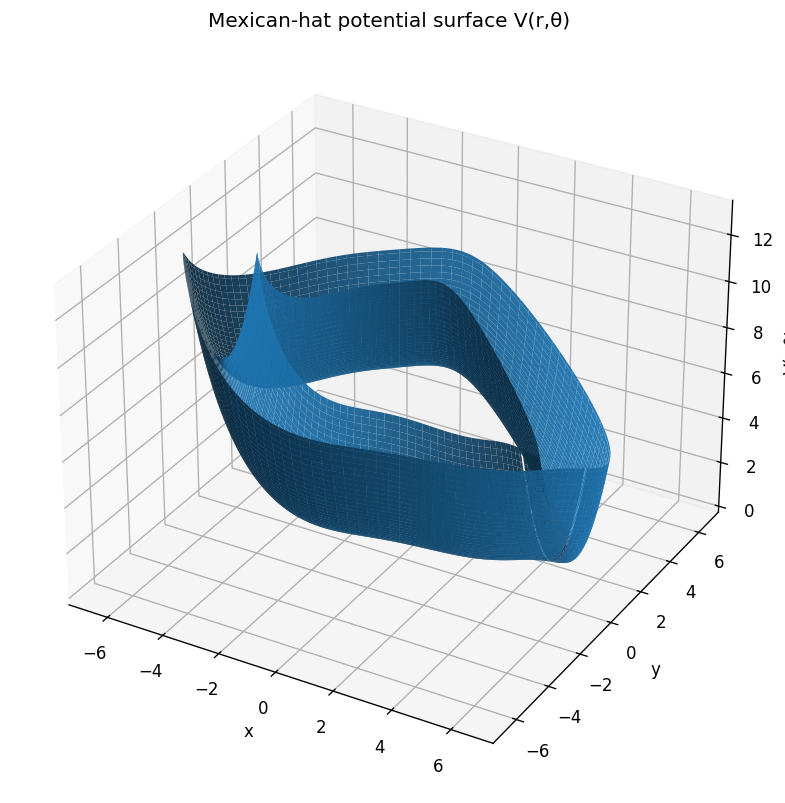

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_mexican_hat_contour.png


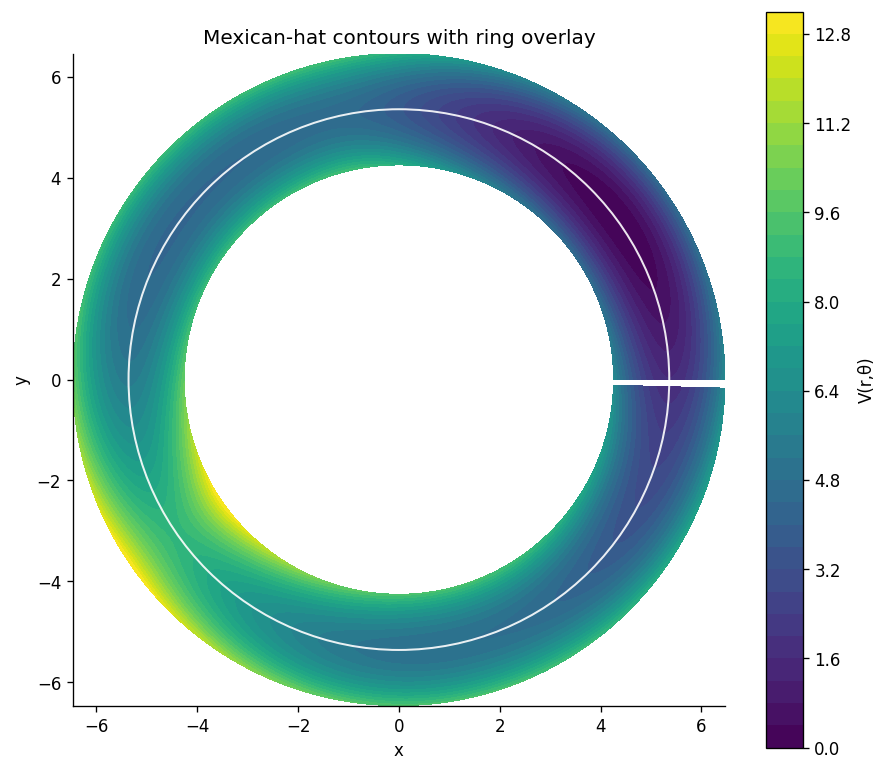

In [23]:
# --- Cell 21: 3D Mexican-hat potential + 2D contours ---
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Periodic interpolator for U(θ)
θg = theta_grid
Ug = U
θ_ext = np.r_[θg, θg + 2*np.pi]
U_ext = np.r_[Ug, Ug]

def U_of_theta(th):
    th = np.mod(th, 2*np.pi)
    return np.interp(th, θg, Ug, period=2*np.pi)

# Build V(r,θ) = U(θ) + 0.5 * ((r - r*)/τ)^2  (a ring well in radius)
τ = sigma_ring if 'sigma_ring' in globals() else (adata.uns.get("gmm_radius",{}).get("sigma",[np.std(adata.obs["radius"])])[0])
r_min = max(0.2, r_star - 3*τ)
r_max = r_star + 3*τ
R = np.linspace(r_min, r_max, 120)
TH = np.linspace(0, 2*np.pi, 240, endpoint=False)
RR, TT = np.meshgrid(R, TH)
V = U_of_theta(TT) + 0.5*((RR - r_star)/(τ+1e-12))**2

# Convert to Cartesian for plotting
XX = RR * np.cos(TT)
YY = RR * np.sin(TT)

# 3D surface (Mexican-hat)
fig = plt.figure(figsize=(8.8, 6.8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XX, YY, V, linewidth=0, antialiased=True, rstride=2, cstride=2, alpha=0.95)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("V(r,θ)")
ax.set_title("Mexican-hat potential surface V(r,θ)")
plt.tight_layout(); savefig("fig04_mexican_hat_surface.png"); plt.show()

# 2D contour of V(r,θ)
fig, ax = plt.subplots(1,1, figsize=(7.6,6.6))
cs = ax.contourf(XX, YY, V, levels=40)
cbar = plt.colorbar(cs, ax=ax); cbar.set_label("V(r,θ)")
# overlay the inferred ring
ax.add_artist(plt.Circle((0,0), r_star, color='w', fill=False, lw=1.2, alpha=0.9))
ax.set_aspect('equal'); ax.set_title("Mexican-hat contours with ring overlay")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); savefig("fig04_mexican_hat_contour.png"); plt.show()


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_flow_on_contour.png


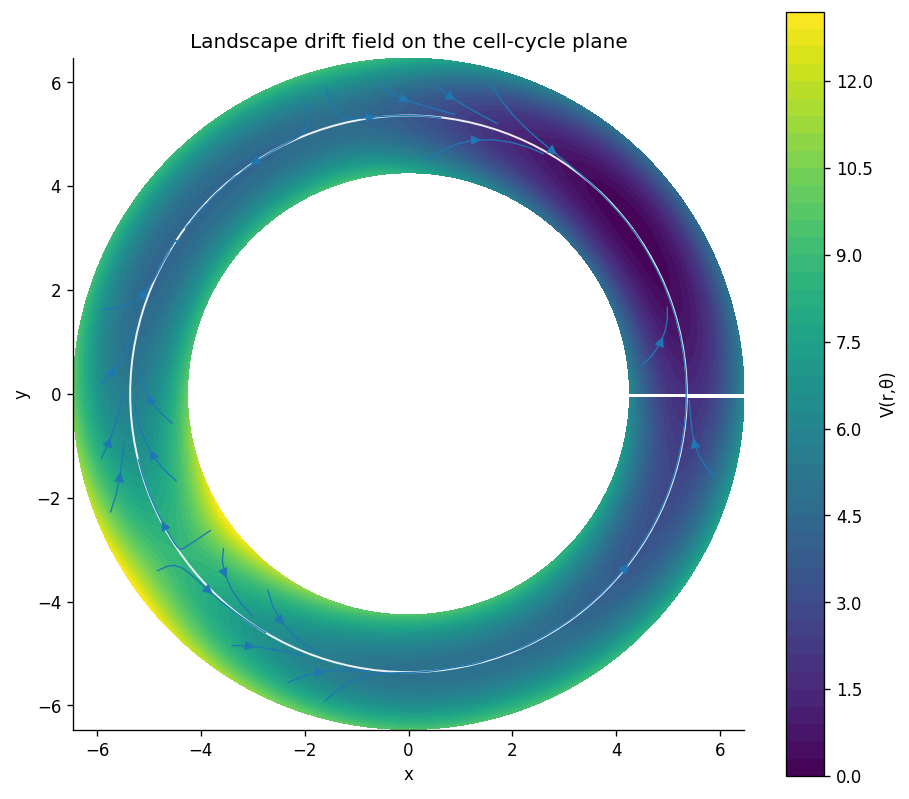

In [24]:
# --- Cell 22: flow field (drift) on the ring plane ---
import numpy as np, matplotlib.pyplot as plt

# angular derivative of U(θ) on the grid (periodic)
dθ = θg[1] - θg[0]
dU = np.gradient(Ug, dθ, edge_order=2)
def dU_of_theta(th):
    th = np.mod(th, 2*np.pi)
    return np.interp(th, θg, dU, period=2*np.pi)

# Vector field on a Cartesian grid
nx = ny = 50
lim = r_star + 2.5*τ
xs = np.linspace(-lim, lim, nx)
ys = np.linspace(-lim, lim, ny)
XX, YY = np.meshgrid(xs, ys)
RR = np.sqrt(XX**2 + YY**2) + 1e-12
TT = np.mod(np.arctan2(YY, XX), 2*np.pi)

# Drift in polar
fr = -(RR - r_star) / (τ**2 + 1e-12)
ft = -dU_of_theta(TT)

# Convert to Cartesian: e_r = (cos, sin), e_t = (-sin, cos)
Ux = fr*np.cos(TT) - ft*np.sin(TT)
Uy = fr*np.sin(TT) + ft*np.cos(TT)

# Mask outside plotting annulus for clarity
mask = (RR >= (r_star - 2.5*τ)) & (RR <= (r_star + 2.5*τ))

# Plot over the contour
fig, ax = plt.subplots(1,1, figsize=(7.8,6.8))
# reuse the potential contour
Rplot = np.linspace(r_min, r_max, 220)
Tplot = np.linspace(0, 2*np.pi, 420, endpoint=False)
RRp, TTp = np.meshgrid(Rplot, Tplot)
XXp = RRp*np.cos(TTp); YYp = RRp*np.sin(TTp)
Vp  = U_of_theta(TTp) + 0.5*((RRp - r_star)/(τ+1e-12))**2
cs = ax.contourf(XXp, YYp, Vp, levels=50)
plt.colorbar(cs, ax=ax, label="V(r,θ)")

# streamplot/quiver
try:
    sp = ax.streamplot(xs, ys, np.where(mask, Ux, np.nan), np.where(mask, Uy, np.nan),
                       density=1.2, linewidth=0.8, arrowsize=1.2)
except Exception:
    ax.quiver(XX[mask], YY[mask], Ux[mask], Uy[mask], scale=80)

# ring overlay
ax.add_artist(plt.Circle((0,0), r_star, color='w', fill=False, lw=1.2, alpha=0.9))
ax.set_aspect('equal'); ax.set_title("Landscape drift field on the cell-cycle plane")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); savefig("fig04_flow_on_contour.png"); plt.show()


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_flux_cone_speed.png


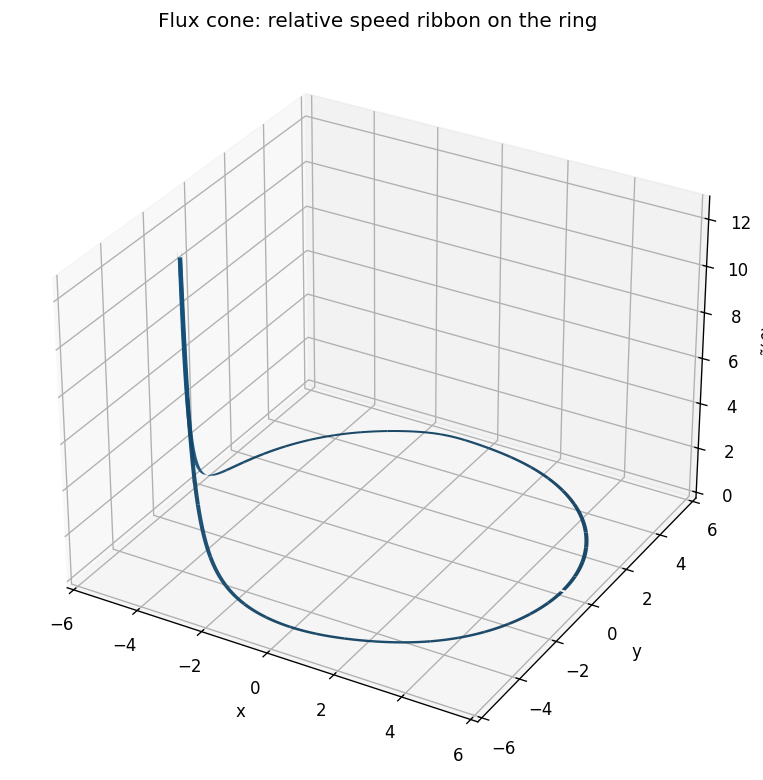

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig04_flux_cone_potential.png


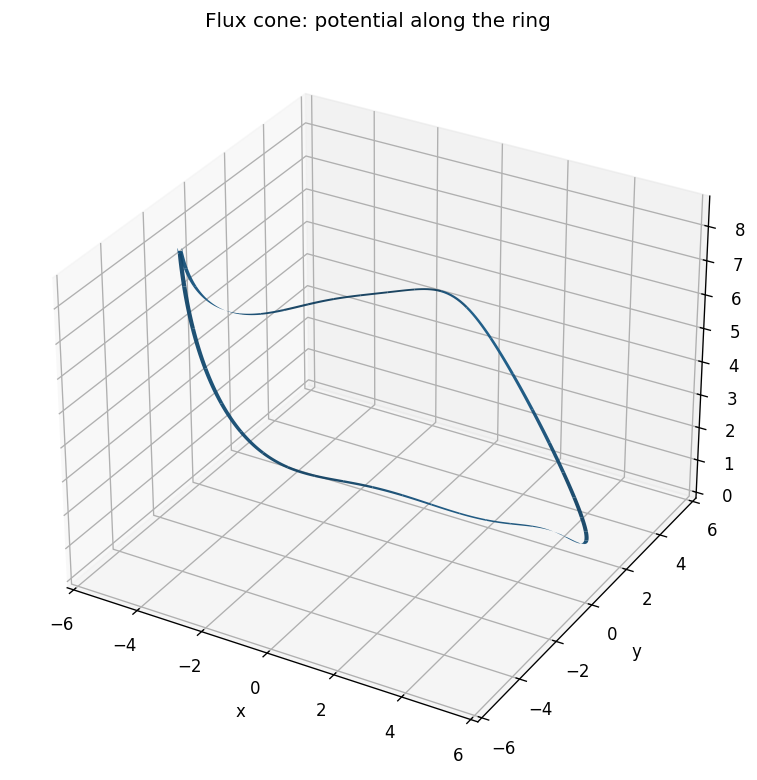

In [25]:
# --- Cell 23: flux cone (3D ring ribbons) ---
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Ensure v_tilde exists (Cell 6 computed it)
assert 'v_tilde' in globals(), "v_tilde not found – run the relative speed cell first."

# Thin ribbon around the ring
δr = 0.15*τ
r_inner = r_star - δr
r_outer = r_star + δr

# Build two rings for a ribbon surface
θr = theta_grid
vθ = v_tilde
Uθ = U

X_in  = r_inner * np.cos(θr); Y_in  = r_inner * np.sin(θr)
X_out = r_outer * np.cos(θr); Y_out = r_outer * np.sin(θr)

def ribbon_surface(X1,Y1,X2,Y2,Z):
    # stack as a quad strip
    X = np.vstack([X1, X2])
    Y = np.vstack([Y1, Y2])
    Z = np.vstack([Z,  Z])
    return X,Y,Z

# 3D: speed ribbon
fig = plt.figure(figsize=(8.2,6.6))
ax = fig.add_subplot(111, projection='3d')
Xs, Ys, Zs = ribbon_surface(X_in, Y_in, X_out, Y_out, vθ)
ax.plot_surface(Xs, Ys, Zs, linewidth=0, antialiased=True, alpha=0.95)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel(r"$\tilde v(\theta)$")
ax.set_title("Flux cone: relative speed ribbon on the ring")
plt.tight_layout(); savefig("fig04_flux_cone_speed.png"); plt.show()

# 3D: potential rim
fig = plt.figure(figsize=(8.2,6.6))
ax = fig.add_subplot(111, projection='3d')
Xp, Yp, Zp = ribbon_surface(X_in, Y_in, X_out, Y_out, Uθ)
ax.plot_surface(Xp, Yp, Zp, linewidth=0, antialiased=True, alpha=0.95)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel(r"$U(\theta)$")
ax.set_title("Flux cone: potential along the ring")
plt.tight_layout(); savefig("fig04_flux_cone_potential.png"); plt.show()


# Summary & hand-off

What we computed. From per-cell phases ($\theta$) and radii ($r$), we built a ring-restricted phase density $P_{\text{ring}}(\theta)$, the potential $U(\theta)=-\ln P_{\text{ring}}(\theta)$, identified barriers (saddles) and basins, derived a relative speed proxy $\tilde v(\theta)\propto 1/P_{\text{ring}}(\theta)$, and estimated a constant ring current $\hat J$ via a least-squares continuity fit (Li–Wang style). We summarized group differences (stage/age) via barrier heights, entropy of $P_{\text{ring}}$, and rotation-invariant circular $W_1$ distances, with bootstrapped CIs.
Sanity checks. Marker alignment (S/G2M) is consistent with the recovered landscape; the two speed definitions ($1/\rho$ vs $\hat J/\rho$) are highly concordant; saddle locations are stable across $(\kappa,\gamma)$ and bootstraps.
Where signal lives. A strong barrier at $\theta\approx 3.7$ rad; late tumors show higher barriers and lower entropy (sharper dwell). Group contrasts show substantial circular $W_1$ (e.g., early–late).
What’s next (Notebook 05).

Formal group comparisons on the ring: per-group $P_{\text{ring}}$, $U$, barrier heights with CIs;

Report circular $W_1$ with uncertainty;

Optional: per-group flux summaries ($\hat J$, constancy).
We’ll also prepare compact, figure-ready panels and a single summary table for the report.